
Analyzing: HPC_1

 path:  /home/admin/Ana/MicroBrain/output/um_gaia/formatted/formatted2/graph_18_OutGeom_um_formatted_Hcut1.pkl

- Graph sanity check

[HPC_1] units: coords/length=um | diameter=vox
BOX bounds:
  x: [1425.000000, 1825.000000]  (size=400.000000)
  y: [5487.500000, 5887.500000]  (size=400.000000)
  z: [3300.000000, 3700.000000]  (size=400.000000)

- Duplicated edges:  {'n_pairs_duplicated': 2, 'n_extra_edges': 2, 'perc_extra_edges': 0.15278838808250572}
- Loops:  {'n_loops': 1, 'perc_loops': 0.07639419404125286, 'loop_indices': [424]}

- Average length by nkind:

nkind=2 (arteriole): mean length = 28.068814
nkind=3 (venule): mean length = 38.127434
nkind=4 (capillary): mean length = 47.734570

- Average diameter by nkind:

arteriole (nkind=2, n=96):
  mean:   6.16
  median: 6.01
  p5–p95: 3.41 – 9.32

venule (nkind=3, n=22):
  mean:   9.22
  median: 9.73
  p5–p95: 6.03 – 11.70

capillary (nkind=4, n=1191):
  mean:   5.31
  median: 5.09
  p5–p95: 4.27 – 7.03



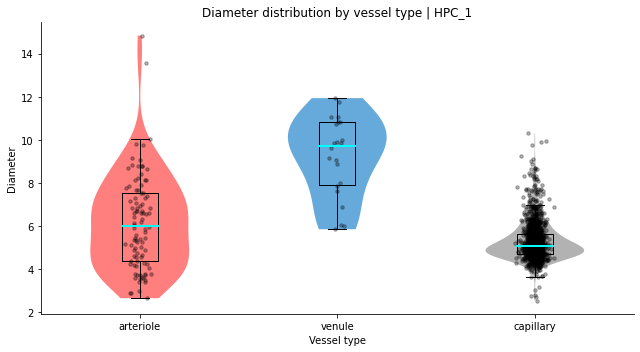

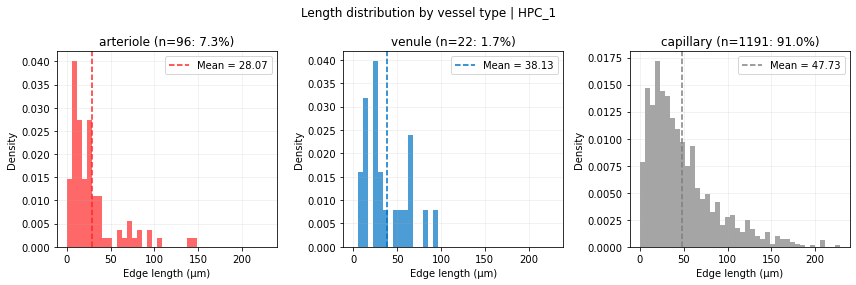

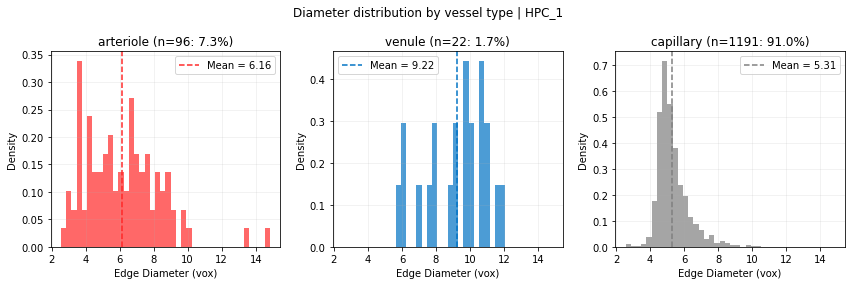


 --- DEGREES --- 

Unique degrees: [1 3 4 5 6]
HDN (>= 4): 66


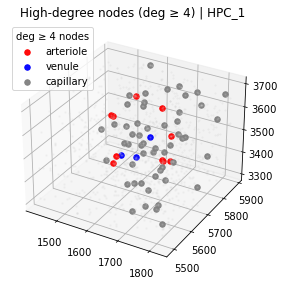


 --- BC ANALYSIS --- 



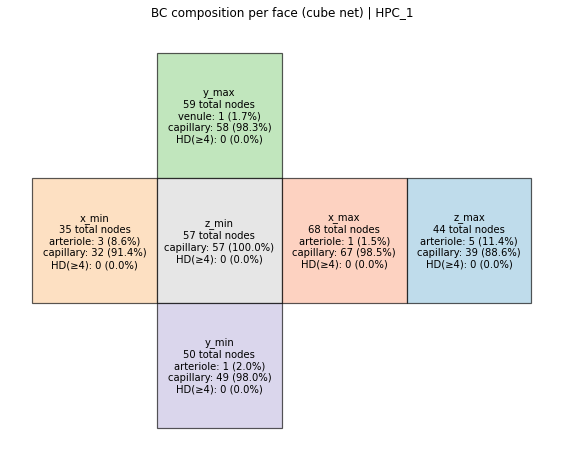

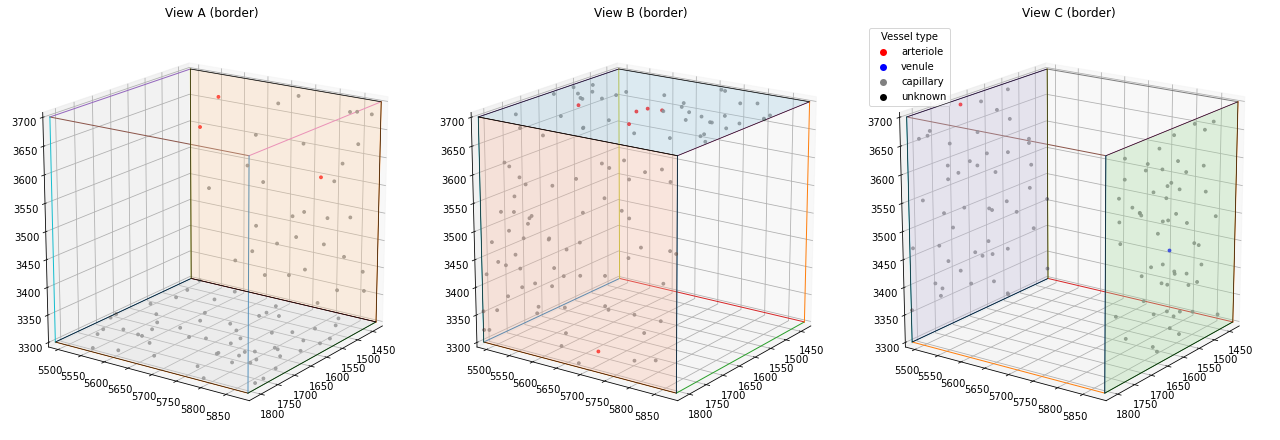


 --- REDUNDANCY --- 

{'graph': 'HPC_1', 'arterioles': 90, 'venules': 13, 'pairs_searched': 1170, 'pairs_with_path': 1170, 'all_connected': True}
A: 120 V: 160
A: 120 V: 164
A: 120 V: 165
A: 120 V: 174
A: 120 V: 180
A: 120 V: 196
A: 120 V: 209
A: 120 V: 562
A: 120 V: 587
A: 120 V: 592
A: 120 V: 609
A: 120 V: 610
A: 120 V: 1017
A: 137 V: 160
A: 137 V: 164
A: 137 V: 165
A: 137 V: 174
A: 137 V: 180
A: 137 V: 196
A: 137 V: 209


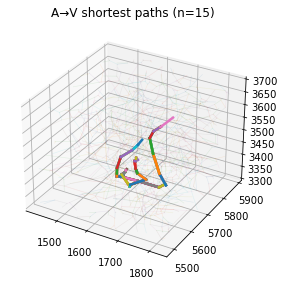

Number of boxes: 343
---- DENSITY CHECK ----
Global density: 0.021218637794417367
Mean box density: 0.022635759128876894
Min density: 0.005364212919101799
Max density: 0.04459675865844548
Mean length density: 988.0197159958888
Total vessel length (µm): 60385.28199965053
Total vessel length (mm): 60.38528199965053
-----------------------


In [ ]:
import os
import sys
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import igraph as ig
from matplotlib.patches import Patch

# ---------------------------------------------------------------------
# formatted analysis toolbox
# ---------------------------------------------------------------------
sys.path.insert(0, "/home/ana/MicroBrain/codes/Graph Analysis & by region/Graph analysis")
from graph_analysis_functions_formatted import *

# ---------------------------------------------------------------------
# paths / params
# ---------------------------------------------------------------------
out_root = "/home/admin/Ana/MicroBrain/output/HPC_FULL_ANALYSIS_FORMATTED"
os.makedirs(out_root, exist_ok=True)

PATHS = {
    "HPC_1": "/home/admin/Ana/MicroBrain/output/um_gaia/formatted/formatted2/graph_18_OutGeom_um_formatted_Hcut1.pkl",
    #"HPC_2": "/home/admin/Ana/MicroBrain/output/um_gaia/formatted/formatted2/graph_18_OutGeom_um_formatted_Hcut2.pkl",
    #"HPC_3": "/home/admin/Ana/MicroBrain/output/um_gaia/formatted/formatted2/graph_18_OutGeom_um_formatted_Hcut3.pkl",
}

HIPPO_CENTERS = [
    [1000, 3500, 1400],
    [1300, 3900, 1000],
    [2100, 4200, 750],
]

box_size_um = (400, 400, 400)

degree_thr = 4
eps_vox = 2.0

# Density settings
slab_um_cutbox = 10.0
slab_axis = "z"

# plotting controls
plot_paths_cap = 15
bins_hist = 40

BOX_ORDER = list(PATHS.keys())
BOX_LABEL = " vs ".join(BOX_ORDER)

VESSEL_COL = {
    "arteriole": "#d62728",
    "venule": "#1f77b4",
    "capillary": "#7f7f7f",
    "unknown": "#c7c7c7",
}
BOX_COL = {
    "HPC_1": "tab:blue",
    "HPC_2": "tab:orange",
    "HPC_3": "tab:green",
}


FACE_GRID = [
    ["y_max", "z_max", "y_min"],
    ["x_min", "z_min", "x_max"],
]


# ---------------------------------------------------------------------
# COLLECTORS
# ---------------------------------------------------------------------
all_summaries = []
diam_long_parts = []
av_path_size_rows = []
av_rows = []
bc_rows = []
hdn_nodes_rows = []
redundancy_rows = []


# density collectors
density_box_values = {}   # heterogeneity values (per slab, %)
density_box_slabs = {}
density_long_rows = []
density_total_rows = []   # one row per box: TOTAL density (whole CutBox, %)

# NEW
graph_density_rows = []   # V/E counts per volume per box



# ---------------------------------------------------------------------
# analysis loop 
# ---------------------------------------------------------------------

for (name, path), center in zip(PATHS.items(), HIPPO_CENTERS):
    print("\n======================")
    print("Analyzing:", name)
    print("======================\n")
    print(" path: ", path)

    
    g = load_graph(path)
    G = keep_giant_component(g)


    print("\n- Graph sanity check\n")
    # unit sanity print
    g_unit = G["unit"] if ("unit" in G.attributes()) else "unknown"

    d_unit = G["diameter_unit"] if ("diameter_unit" in G.attributes()) else "unknown"

    print(f"[{name}] units: coords/length={g_unit} | diameter={d_unit}")

    # Cutbox in um
    cut_box = make_box_in_um(center, box_size_um, res_um_per_vox=res_um_per_vox)

    validate_box_faces(cut_box)

    print(
        "BOX bounds:\n"
        f"  x: [{cut_box['xmin']:.6f}, {cut_box['xmax']:.6f}]  (size={cut_box['xmax'] - cut_box['xmin']:.6f})\n"
        f"  y: [{cut_box['ymin']:.6f}, {cut_box['ymax']:.6f}]  (size={cut_box['ymax'] - cut_box['ymin']:.6f})\n"
        f"  z: [{cut_box['zmin']:.6f}, {cut_box['zmax']:.6f}]  (size={cut_box['zmax'] - cut_box['zmin']:.6f})\n"
    )

    # NEW: graph density table row (V/E per mm^3, VLD) TODO: WHAT? 
    #graph_density_rows.append(graph_density_row(G, cut_box, name, region="HPC"))


    # --- Basic stats
    dup = duplicated_edge_stats(G)
    loops = loop_edge_stats(G)
    print("- Duplicated edges: ", dup)
    print("- Loops: ", loops)

    # --- Lengths / diameters by type
    avg_len_dict = get_avg_length_nkind(G)
    avg_len_by_type = {EDGE_NKIND_TO_LABEL.get(int(k), str(k)): float(v) for k, v in avg_len_dict.items()}
    diam_stats = diameter_stats_nkind(G, label_dict=EDGE_NKIND_TO_LABEL, plot=True, title_suffix=name)

    # --- per-edge diameter/length
    e_diam = np.asarray(G.es["diameter"], float)
    e_leng = np.asarray(G.es["length"], float)  # um
    nk = np.asarray(G.es["nkind"], int)

    # edge type composition counts for summary
    etype_counts = edge_type_counts(nk, EDGE_NKIND_TO_LABEL)
    E_arteriole = int(etype_counts["arteriole"])
    E_venule = int(etype_counts["venule"])
    E_capillary = int(etype_counts["capillary"])
    E_unknown = int(etype_counts["unknown"])

    for k in np.unique(nk):
        lab = EDGE_NKIND_TO_LABEL.get(int(k), str(k))
        m = (nk == k)
        if np.any(m):
            diam_long_parts.append(pd.DataFrame({
                "graph": name,
                "type": str(lab),
                "diameter_vox": e_diam[m],
                "length_um": e_leng[m],
            }))

    # per-box length distribution by type
    plot_hist_by_category_general(
        values=e_leng,
        category=nk,
        label_dict=EDGE_NKIND_TO_LABEL,
        bins=bins_hist,
        layout="horizontal",
        density=True,
        show_mean=True,
        variable_name="Edge length (µm)",
        category_name="Vessel type",
        main_title=f"Length distribution by vessel type | {name}"
    )

    # per-box diameter distribution by type
    plot_hist_by_category_general(
        values=e_diam,
        category=nk,
        label_dict=EDGE_NKIND_TO_LABEL,
        bins=bins_hist,
        layout="horizontal",
        density=True,
        show_mean=True,
        variable_name="Edge Diameter (vox)",
        category_name="Vessel type",
        main_title=f"Diameter distribution by vessel type | {name}"
    )

    print("\n --- DEGREES --- \n")
    # degrees and high degree nodes
    get_degrees(G, threshold=degree_thr)

    hdn = analyze_hdn_pattern_in_box(
        G,
        box=cut_box,
        coords_attr="coords",
        space="um",
        degree_thr=degree_thr,
        eps_vox=eps_vox
    )

    deg = np.asarray(G.degree(), int)
    hdn_nodes = np.where(deg >= degree_thr)[0]
    coords = np.asarray(G.vs["coords"], float)

    for v in hdn_nodes:
        t = infer_node_type_from_incident_edges(G, int(v))
        x, y, z = coords[int(v)]
        hdn_nodes_rows.append({
            "graph": name,
            "v": int(v),
            "x": float(x), "y": float(y), "z": float(z),
            "degree": int(deg[int(v)]),
            "type": t
        })

    plot_degree_nodes_spatial(
        G,
        coords_attr="coords",
        degree_min=degree_thr,
        degree_max=None,
        by_type=True,
        title=f"High-degree nodes (deg ≥ {degree_thr}) | {name}"
    )


    print("\n --- BC ANALYSIS --- \n")

    # --- BC faces analysis
    bc = analyze_bc_faces(
        G,
        cut_box,
        coords_attr="coords",
        space="um",
        eps_vox=eps_vox,
        degree_thr=degree_thr,
        mode="border"
    )

    # Debug vertices close to each face plane:
    # debug_face_plane_counts(G, cut_box, coords_attr="coords", eps_vox=eps_vox, space="um")

    bc_df = bc_faces_table(bc, box_name=name).copy()
    bc_df["graph"] = name

    # % come from analyze_bc_faces
    for vname, pcol in {
            "arteriole": "% Arteriole",
            "venule": "% Venule",
            "capillary": "% Capillary",
    }.items():
        # for each nkind, creates a new column with its count
        bc_df[f"n_{vname}"] = (
            pd.to_numeric(bc_df["BC nodes"], errors="coerce").fillna(0.0) *
            pd.to_numeric(bc_df[pcol], errors="coerce").fillna(0.0) / 100.0
        )

    bc_rows.append(bc_df)
    

    plot_bc_cube_net(bc, title=f"BC composition per face (cube net) | {name}")
    plot_bc_3_cubes_tinted(G, cut_box, coords_attr="coords", space="um", eps_vox=eps_vox, mode="border")


    print("\n --- REDUNDANCY --- \n")
    # --- Redundancy/Resilience 
    # shortest A->V paths
    shortest_paths = shortest_av_paths(G)
    for p in shortest_paths:
            # keeps info of length of path per path
            av_path_size_rows.append({"graph": name, "path_len_edges": int(len(p) - 1)})
    # keeps info of number of A-V, pairs searched, with path and connected        
    av_rows.append(av_path_stats(G, name, shortest_paths))
    print(av_path_stats(G, name, shortest_paths))
    
    
    if shortest_paths:
        sampled_paths_1 = sample_paths(shortest_paths, n=20)
        for p in sampled_paths_1:
            print("A:", p[0], "V:", p[-1])

        export_paths_vtp(
            G,
            sampled_paths_1,
            os.path.join(out_root, f"{name}_example_AV_paths_1.vtp")
        )


    
        #>>>>> this could be deleted if i am doing visualization in paraview
        plot_av_paths_in_box(
                G,
                cut_box,
                shortest_paths[:plot_paths_cap],
                coords_attr="coords",
                node_eps=0.0
        )
        # <<<<

    # --- Edge-disjoint paths (maxflow)
    redundancy = max_edge_disjoint_av(G)
    n_disjoint = int(redundancy["n_edge_disjoint_av"])
    nA = int(redundancy["nA"])
    nV = int(redundancy["nV"])
    independent_paths = redundancy["paths"]
    
    redundancy_rows.append({
            "graph": name,
            "edge_disjoint_AV": n_disjoint,
            "A_nodes": nA,
            "V_nodes": nV,
            "shortest_paths_n": int(len(shortest_paths)),
            "shortest_path_len_median": float(np.median([len(p) - 1 for p in shortest_paths])) if shortest_paths else np.nan,
            "shortest_path_len_p90": float(np.percentile([len(p) - 1 for p in shortest_paths], 90)) if shortest_paths else np.nan,
    })

    export_paths_vtp(
            G,
            independent_paths,
            os.path.join(out_root, f"{name}_example_INDEP_AV_paths_1.vtp")
    )


    # -- Vessel density
    ms = microsegments_from_formatted_graph(G)


    boxes = generate_boxes(cut_box)

    rows = []

    for b in boxes:

        vvd = vessel_volume_density(ms,b)
        vld = vessel_length_density(ms,b)

        rows.append({
            "graph": name,   # HPC_1, HPC_2, SMC_1 etc
            "vessel_vol_density": vvd,
            "vessel_length_density": vld
        })

    df_density = pd.DataFrame(rows)

    # sanity check 1
    global_density = vessel_volume_density(ms, cut_box)
    boxes = generate_boxes(cut_box)

    print("Number of boxes:", len(boxes))
    print("---- DENSITY CHECK ----")
    print("Global density:", global_density)
    print("Mean box density:", np.nanmean(df_density["vessel_vol_density"]))
    print("Min density:", np.nanmin(df_density["vessel_vol_density"]))
    print("Max density:", np.nanmax(df_density["vessel_vol_density"]))
    print("Mean length density:",
        np.nanmean(df_density["vessel_length_density"]))
    total_length_um = np.sum(ms["lengths"])
    total_length_mm = total_length_um * 1e-3

    print("Total vessel length (µm):", total_length_um)
    print("Total vessel length (mm):", total_length_mm)
    print("-----------------------")

    # sanity check 2
    # Graph density for simple undirected graphs = (2 * E / (V * (V - 1)))
    graph_density_metrics(G, name)







In [3]:
ms = microsegments_from_formatted_graph(G)



boxes = generate_boxes(cut_box)

rows = []

for b in boxes:

    vvd = vessel_volume_density(ms,b)
    vld = vessel_length_density(ms,b)

    rows.append({
        "graph": name,   # HPC_1, HPC_2, SMC_1 etc
        "vessel_vol_density": vvd,
        "vessel_length_density": vld
    })

df_density = pd.DataFrame(rows)


plot_density_boxplot(df_density, "vessel_vol_density",
                     "Vessel volume density HPC vs SMC")

plot_density_slabs(df_density, "hola")



NameError: name 'plot_density_boxplot' is not defined

In [ ]:




    # -----------------------------------------------------------------
    # Vessel density in CutBox FROM SCRATCH
    # -----------------------------------------------------------------
    density_mean_cutbox = np.nan
    density_total_cutbox_pct = np.nan  # whole box in %

    mc = build_microcylinders_from_formatted_graph(
        G,
        res_um_per_vox=res_um_per_vox,
        default_coord_unit="um",
        default_diameter_unit="vox",
        label_dict=EDGE_NKIND_TO_LABEL,
        sanity_check=True,
    )

    # (B) TOTAL density
    tot = vessel_vol_frac_total_in_box_from_mc(mc, cut_box)
    density_total_cutbox_pct = float(tot["total_vol_frac_pct"])  # already in %

    density_total_rows.append({
        "graph": name,
        "total_vol_frac_pct": float(tot.get("total_vol_frac_pct", np.nan)),
        "vessel_vol": float(tot.get("vessel_vol", np.nan)),
        "tissue_vol": float(tot.get("tissue_vol", np.nan)),
        "arteriole_vol_frac_pct": float(tot.get("arteriole_vol_frac_pct", np.nan)),
        "venule_vol_frac_pct": float(tot.get("venule_vol_frac_pct", np.nan)),
        "capillary_vol_frac_pct": float(tot.get("capillary_vol_frac_pct", np.nan)),
        "unknown_vol_frac_pct": float(tot.get("unknown_vol_frac_pct", np.nan)),
        "n_microcyl_hit": int(tot.get("n_microcyl_hit", 0)),
    })

    # (A) slabs profile
    df_box = vessel_vol_frac_slabs_in_box_from_mc(
        mc,
        cut_box,
        slab=slab_um_cutbox,
        axis=slab_axis,
        do_sanity=True
    )
    density_box_slabs[name] = df_box.copy()

    # NEW: keep vessel volume per 10^3 µm^3 tissue
    df_box["vessel_vol_per_1e3_um3"] = 1e3 * df_box["total_vol_frac"]

    # NEW: diagnostics
    slab_density_diagnostics(df_box, tot, name)

    # store slab densities (%)
    y_box = df_box["total_vol_frac_pct"].to_numpy(float)
    y_box = y_box[np.isfinite(y_box)]
    density_box_values[name] = y_box
    density_mean_cutbox = float(np.nanmean(y_box)) if y_box.size else np.nan

    for v in y_box:
        density_long_rows.append({"graph": name, "slab_vol_frac_pct": float(v)})

    df_box.to_csv(
        os.path.join(out_root, f"{name}_CutBox_density_slabs_{int(slab_um_cutbox)}um.csv"),
        index=False
    )

    # plots: density (%) + vessel volume / 10^3 µm^3
    try:
        plot_intra_box_heterogeneity(df_box, name, slab_um_cutbox)
        plot_slabs_vessel_vol_per_1e3(df_box, name, slab_um_cutbox, axis=slab_axis)
    except Exception as e:
        print(f"[{name}] plot intra-box failed:", e)









    # --- Distance to surface
    d2s_mean = np.nan
    d2s_median = np.nan
    if ("distance_to_surface_R" in G.vs.attributes()) or ("distance_to_surface" in G.vs.attributes()):
        nodes = np.arange(G.vcount())
        d2s = distance_to_surface_stats(G, nodes, space="um")
        d2s_mean = float(d2s["mean"])
        d2s_median = float(d2s["median"])


    # --- Summary row
    summary = {
        "graph": name,
        "V": int(G.vcount()),
        "E": int(G.ecount()),
        "dup_%": float(dup["perc_extra_edges"]),
        "loops_%": float(loops["perc_loops"]),
        "HDN_n": int(hdn.get("n_hdn", 0)),
        "HDN_frac": float(hdn.get("hdn_fraction", 0.0)),
        "shortest_paths_n": int(len(shortest_paths)),
        "edge_disjoint_AV": int(n_disjoint),
        "A_nodes": int(nA),
        "V_nodes": int(nV),

        "E_arteriole": int(E_arteriole),
        "E_venule": int(E_venule),
        "E_capillary": int(E_capillary),
        "E_unknown": int(E_unknown),

        # slab heterogeneity summary (mean across slabs, %)
        "density_mean_cutbox_%": float(density_mean_cutbox) if np.isfinite(density_mean_cutbox) else np.nan,

        # one-number whole CutBox density (%)
        "density_total_cutbox_%": float(density_total_cutbox_pct) if np.isfinite(density_total_cutbox_pct) else np.nan,

        "d2s_mean": float(d2s_mean) if np.isfinite(d2s_mean) else np.nan,
        "d2s_median": float(d2s_median) if np.isfinite(d2s_median) else np.nan,
    }

    # Add VLD to summary (explicit)
    vol_box = (cut_box["xmax"] - cut_box["xmin"]) * (cut_box["ymax"] - cut_box["ymin"]) * (cut_box["zmax"] - cut_box["zmin"])
    vld = np.nansum(safe_arr(G.es["length"], float)) / vol_box  # µm/µm³
    summary["VLD_mm_per_mm3"] = float(vld * 1e6)  # mm/mm³

    # avg length by type
    for nm, val in avg_len_by_type.items():
        summary[f"avg_len_{nm}_um"] = float(val)

    # diameter stats by type
    for _, st in diam_stats.items():
        nm = st["name"]
        summary[f"diam_mean_{nm}_proxy_um"] = float(st["mean"])
        summary[f"diam_median_{nm}_proxy_um"] = float(st["median"])
        summary[f"diam_p5_{nm}_proxy_um"] = float(st["p5"])
        summary[f"diam_p95_{nm}_proxy_um"] = float(st["p95"])

    all_summaries.append(summary)

    # save per-box CSVs
    pd.DataFrame([summary]).to_csv(os.path.join(out_root, f"{name}_summary.csv"), index=False)
    bc_df.to_csv(os.path.join(out_root, f"{name}_bc_faces.csv"), index=False)

# ---------------------------------------------------------------------
# Store summary
# ---------------------------------------------------------------------
summary_df = pd.DataFrame(all_summaries)
summary_csv = os.path.join(out_root, "HPC_summary_COMPARISON.csv")
summary_df.to_csv(summary_csv, index=False)
print("\nSaved:", summary_csv)

# Optional: print stability across boxes
summarize_ratio_stability(summary_df, cols=("ratio_median_A_over_C", "ratio_median_V_over_C"))

# =====================================================================
# GLOBAL FIGURES
# =====================================================================
BOX_LABEL = " vs ".join(BOX_ORDER)

# Diameter/Length distributions per type
if diam_long_parts:
    dl = pd.concat(diam_long_parts, ignore_index=True)
    dl["type"] = dl["type"].astype(str)

    diameter_length_overlay_by_type(dl, bins=bins_hist, box_label=BOX_LABEL)

    for t in sorted(dl["type"].unique()):
        sub = dl[dl["type"] == t].copy()
        plot_boxplot_by_graph(sub, "diameter_vox", title=f"Diameter boxplot | type={t}", ylabel="Diameter (vox)")
        plot_boxplot_by_graph(sub, "length_um", title=f"Length boxplot | type={t}", ylabel="Length (µm)")
        
    out_hpc = os.path.join(out_root, "HPC_diam_length_long.csv")
    dl.to_csv(out_hpc, index=False)
    print("Saved:", out_hpc)
    print("graphs:", sorted(dl["graph"].unique()))

# CutBox density heterogeneity (10 µm) -> boxplot per CutBox
if density_box_values:
    order = [g for g in BOX_ORDER if g in density_box_values]
    groups = [safe_finite(density_box_values[g]) for g in order]

    plt.figure(figsize=(7, 5))
    plt.boxplot(groups, labels=order, showfliers=False)
    plt.title(f"CutBox vessel density heterogeneity | slab={int(slab_um_cutbox)} µm | {BOX_LABEL}")
    plt.ylabel("Vessel volume fraction per slab (%)")
    plt.grid(alpha=0.25, axis="y")
    plt.tight_layout()
    plt.show()

    pd.DataFrame(density_long_rows).to_csv(
        os.path.join(out_root, f"CutBox_density_long_{int(slab_um_cutbox)}um.csv"),
        index=False
    )

# TOTAL density between boxes (one value per box) -> save + barplot
if density_total_rows:
    df_total = pd.DataFrame(density_total_rows).copy()
    df_total["total_vol_frac_pct"] = pd.to_numeric(df_total["total_vol_frac_pct"], errors="coerce")

    df_total = df_total.groupby("graph", as_index=False).mean(numeric_only=True)
    df_total = df_total.set_index("graph").reindex(BOX_ORDER).reset_index()

    total_csv = os.path.join(out_root, "CutBox_density_TOTAL_between_boxes.csv")
    df_total.to_csv(total_csv, index=False)
    print("Saved:", total_csv)

    labels = df_total["graph"].astype(str).to_numpy()
    vals = df_total["total_vol_frac_pct"].to_numpy(float)

    plt.figure(figsize=(6.5, 4.5))
    plt.bar(labels, vals)
    plt.title("CutBox vessel density (TOTAL) — between boxes")
    plt.ylabel("Vessel volume fraction (%)")
    plt.grid(alpha=0.25, axis="y")
    plt.tight_layout()
    plt.show()

# Shortest path length distribution (#edges): overlay hist + boxplot
if path_len_rows:
    pldf = pd.DataFrame(path_len_rows)

    plot_hist_overlay(
        pldf, "path_len_edges",
        title=f"Shortest A→V path length (#edges) | {BOX_LABEL}",
        xlabel="Path length (#edges)",
        bins=30,
    )
    plot_boxplot_by_graph(
        pldf, "path_len_edges",
        title=f"Shortest A→V path length (#edges) | {BOX_LABEL}",
        ylabel="Path length (#edges)",
    )

print("\nGLOBAL figures generated in:", out_root)


# ---------------------------------------------------------------------
# BC cube-net compare (per face, per box, stacked by vessel type)
# + save faces x graphs table
# ---------------------------------------------------------------------
if len(bc_rows) == 0:
    print("[BC] bc_rows is empty -> nothing to plot.")

else:
    bc_all = pd.concat(bc_rows, ignore_index=True)

    # ------------------------------------------------
    # 0) sanity: required columns
    # ------------------------------------------------
    required = ["Face", "graph", "BC nodes"]
    missing = [c for c in required if c not in bc_all.columns]
    if missing:
        print("[BC] Missing required columns:", missing)
        print("[BC] Available columns:", bc_all.columns.tolist())
    else:
        # ------------------------------------------------
        # 1) construir tabla faces x graphs
        # ------------------------------------------------
        df_faces = make_bc_face_table_from_bc_all(
            bc_all,
            face_col="Face",
            graph_col="graph",
            value_col="BC nodes",
            face_order=("x_min", "x_max", "y_min", "y_max", "z_min", "z_max"),
            graph_order=BOX_ORDER
        )

        # ------------------------------------------------
        # 2) guardar tabla (paper)
        # ------------------------------------------------
        save_bc_table_paper(
            df_faces,
            os.path.join(out_root, "BC_nodes_faces_table.png"),
            title="Boundary condition nodes per face"
        )
        df_faces.to_csv(os.path.join(out_root, "BC_nodes_faces_table.csv"), index=True)

        # ------------------------------------------------
        # 3) cube-net plots (robust face matching)
        # ------------------------------------------------
        bc_all = bc_all.copy()
        plot_cube_net_counts_per_face(
        bc_all,
        out_path=os.path.join(out_root, "BC_cube_net_counts_per_face.png"),
        title=f"BC nodes per face | {BOX_LABEL}",
        box_order=BOX_ORDER
        )
        # normalize Face labels so filtering works
        bc_all["Face"] = bc_all["Face"].astype(str).str.strip().str.lower()
        bc_all["Face"] = bc_all["Face"].replace({
            "xmin": "x_min", "xmax": "x_max",
            "ymin": "y_min", "ymax": "y_max",
            "zmin": "z_min", "zmax": "z_max",
            "x min": "x_min", "x max": "x_max",
            "y min": "y_min", "y max": "y_max",
            "z min": "z_min", "z max": "z_max",
        })

        print("[BC] Faces in bc_all (normalized):", sorted(bc_all["Face"].unique()))

        face_col = "Face"  # guaranteed now

        # columns used for stacked composition
        COLMAP = {
            "arteriole": "n_arteriole",
            "venule": "n_venule",
            "capillary": "n_capillary",
            "unknown": "n_unknown",
        }
        total_col = "BC nodes"

        # ensure numeric columns exist
        for col in list(COLMAP.values()) + [total_col]:
            if col not in bc_all.columns:
                bc_all[col] = 0.0
            bc_all[col] = pd.to_numeric(bc_all[col], errors="coerce").fillna(0.0)

        fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharey=True)
        fig.suptitle(f"Boundary conditions | cube-net compare | {BOX_LABEL}", fontsize=14)

        for r in range(2):
            for c in range(3):
                face = FACE_GRID[r][c]  # must be x_min, x_max, ...
                ax = axes[r, c]

                sub = bc_all.loc[bc_all[face_col] == face].copy()

                if sub.empty:
                    ax.set_title(face)
                    ax.text(0.5, 0.5, "no data", ha="center", va="center")
                    ax.set_xticks([])
                    ax.set_yticks([])
                    continue

                group_cols = list(COLMAP.values()) + [total_col]
                sub = sub.groupby("graph", as_index=False)[group_cols].sum()

                x = np.arange(len(BOX_ORDER))
                bottom = np.zeros(len(BOX_ORDER), float)

                # stacked bars by vessel type
                for vname in ["arteriole", "venule", "capillary", "unknown"]:
                    col = COLMAP[vname]
                    vals = np.array([
                        float(sub.loc[sub["graph"] == g, col].iloc[0]) if (sub["graph"] == g).any() else 0.0
                        for g in BOX_ORDER
                    ], dtype=float)

                    ax.bar(
                        x, vals, bottom=bottom,
                        label=vname if (r == 0 and c == 0) else None,  # legend once
                        color=VESSEL_COL.get(vname, "lightgrey")
                    )
                    bottom += vals

                # total dots
                totv = np.array([
                    float(sub.loc[sub["graph"] == g, total_col].iloc[0]) if (sub["graph"] == g).any() else 0.0
                    for g in BOX_ORDER
                ], dtype=float)
                ax.plot(x, totv, "k.", markersize=8, label="total" if (r == 0 and c == 0) else None)

                # write totals inside subplot
                for i, g in enumerate(BOX_ORDER):
                    n = int(round(totv[i])) if np.isfinite(totv[i]) else 0
                    ax.text(
                        0.02, 0.95 - 0.10 * i, f"{g}: {n}",
                        transform=ax.transAxes,
                        ha="left", va="top", fontsize=10,
                        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.7, edgecolor="none")
                    )

                ax.set_title(face)
                ax.set_xticks(x)
                ax.set_xticklabels(BOX_ORDER)
                ax.grid(alpha=0.25, axis="y")

        handles, labels = axes[0, 0].get_legend_handles_labels()
        fig.legend(handles, labels, loc="lower center", ncol=5, frameon=False)
        plt.tight_layout(rect=[0, 0.06, 1, 0.95])
        plt.show()
# ---------------------------------------------------------------------
# Redundancy: shortest path length ECDF + medians
# ---------------------------------------------------------------------
if path_len_rows:
    sp = pd.DataFrame(path_len_rows)

    plt.figure(figsize=(7.5, 5))
    for g in BOX_ORDER:
        x = sp.loc[sp["graph"] == g, "path_len_edges"].to_numpy(float)
        x = x[np.isfinite(x)]
        if not x.size:
            continue
        xs, ys = ecdf_xy(x)
        plt.plot(xs, ys, label=g, color=BOX_COL.get(g, None))
        plt.axvline(float(np.median(xs)), color=BOX_COL.get(g, None), linestyle="--", alpha=0.8)

    plt.title(f"Shortest A→V path length (ECDF) | {BOX_LABEL}")
    plt.xlabel("Path length (#edges)")
    plt.ylabel("ECDF")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------------------
# Edge-disjoint (maxflow) as bars
# ---------------------------------------------------------------------
if redundancy_rows:
    ed = pd.DataFrame(redundancy_rows).set_index("graph").reindex(BOX_ORDER)

    plt.figure(figsize=(6.5, 4.5))
    plt.bar(BOX_ORDER, ed["edge_disjoint_AV"].to_numpy(float))
    plt.title(f"Edge-disjoint A→V paths (maxflow) | {BOX_LABEL}")
    plt.ylabel("# edge-disjoint paths")
    plt.grid(alpha=0.25, axis="y")
    plt.tight_layout()
    plt.show()

# grouped boxplots
if diam_long_parts:
    dl = pd.concat(diam_long_parts, ignore_index=True)
    dl["type"] = dl["type"].astype(str)
    plot_grouped_boxplot_types_per_graph(
        dl,
        value_col="diameter_vox",
        type_col="type",
        graphs_order=BOX_ORDER,
        types_order=("arteriole", "venule", "capillary"),
        type_colors=VESSEL_COL,
        title=f"Diameter grouped boxplots (3 vessel types per HPC) | {BOX_LABEL}",
        ylabel="Diameter (vox)"
    )
    plot_grouped_boxplot_types_per_graph(
        dl,
        value_col="length_um",
        type_col="type",
        graphs_order=BOX_ORDER,
        types_order=("arteriole", "venule", "capillary"),
        type_colors=VESSEL_COL,
        title=f"Length grouped boxplots (3 vessel types per HPC) | {BOX_LABEL}",
        ylabel="Length (µm)"
    )

# ---------------------------------------------------------------------
# NEW: Save & print graph density counts table (V/E per volume)
# ---------------------------------------------------------------------
df_gdens = pd.DataFrame(graph_density_rows)
print("\n[Graph density counts]")
print(df_gdens[["region", "graph", "V", "E", "V_per_mm3", "E_per_mm3", "VLD_mm_per_mm3"]])

df_gdens.to_csv(os.path.join(out_root, "graph_density_counts.csv"), index=False)
print("Saved:", os.path.join(out_root, "graph_density_counts.csv"))

IndentationError: expected an indented block after 'if' statement on line 156 (4022211734.py, line 157)

In [ ]:
density_total = float(tot["total_vol_frac_pct"])
density_mean_slabs = float(np.nanmean(df_box["total_vol_frac_pct"]))

print(f"[{name}] TOTAL density (%): {density_total:.6f}")
print(f"[{name}] MEAN slab density (%): {density_mean_slabs:.6f}")
print(f"[{name}] diff (mean - total): {(density_mean_slabs - density_total):.6f} %")

In [ ]:
print(G["diameter_unit"])

In [ ]:
# After loading G, before density calculation:
coords = np.asarray(G.vs["coords"], float)
pts_sample = np.asarray(G.es[0]["points"], float)
print(f"coords range: x [{coords[:,0].min():.1f}, {coords[:,0].max():.1f}]")
print(f"points[0] range: [{pts_sample[:,0].min():.1f}, {pts_sample[:,0].max():.1f}]")
print(f"G['unit'] = {G['unit'] if 'unit' in G.attributes() else 'missing'}")
# Are points in same space as coords?
print(f"coords[0]: {coords[0]}")
print(f"edge 0 point 0: {pts_sample[0]}")

In [ ]:
# =====================================================================
# NEW: DIAMETER + LENGTH consistency across boxes (minimal & meaningful)
#   - One grid plot (types x [diam, length])
#   - One EMD/Wasserstein distance heatmap (2 rows x 3 types)
#   - One CSV summary (median/IQR/CV + CV_between across box medians)
# =====================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- distance: Wasserstein if SciPy, else quantile-based approximation ----
try:
    from scipy.stats import wasserstein_distance as _w1
except Exception:
    _w1 = None

def _finite(x):
    x = np.asarray(x, float)
    return x[np.isfinite(x)]

def _cv_pct(x):
    x = _finite(x)
    if x.size < 2:
        return np.nan
    mu = float(np.mean(x))
    sd = float(np.std(x, ddof=1))
    return np.nan if abs(mu) < 1e-12 else 100.0 * sd / mu

def emd_1d(a, b, qgrid=2000):
    """1D distribution distance. Uses SciPy Wasserstein if available; otherwise quantile-approx."""
    a = _finite(a); b = _finite(b)
    if a.size == 0 or b.size == 0:
        return np.nan
    if _w1 is not None:
        return float(_w1(a, b))
    qs = np.linspace(0.0, 1.0, qgrid)
    qa = np.quantile(a, qs)
    qb = np.quantile(b, qs)
    return float(np.mean(np.abs(qa - qb)))

def sample_for_plot(x, max_n=20000, seed=0):
    x = _finite(x)
    if x.size <= max_n:
        return x
    rng = np.random.default_rng(seed)
    idx = rng.choice(x.size, size=max_n, replace=False)
    return x[idx]

def normalize_type_labels(dl):
    df = dl.copy()
    df["type"] = df["type"].astype(str).str.lower().str.strip()
    df["type"] = df["type"].replace({
        "artery": "arteriole",
        "arterial": "arteriole",
        "vein": "venule",
        "venous": "venule",
        "cap": "capillary",
    })
    return df

def summary_by_box_type(df, value_col, types_order, graphs_order):
    rows = []
    for t in types_order:
        for g in graphs_order:
            x = df.loc[(df["type"] == t) & (df["graph"] == g), value_col].to_numpy(float)
            x = _finite(x)
            if x.size == 0:
                continue
            q25, q50, q75 = np.percentile(x, [25, 50, 75])
            rows.append({
                "metric": value_col,
                "type": t,
                "graph": g,
                "n": int(x.size),
                "median": float(q50),
                "iqr": float(q75 - q25),
                "mean": float(np.mean(x)),
                "std": float(np.std(x, ddof=1)) if x.size > 1 else np.nan,
                "cv_within_pct": float(_cv_pct(x)),
            })

        # between-box variability of medians (one number per type+metric)
        meds = [r["median"] for r in rows if (r["metric"] == value_col and r["type"] == t)]
        if len(meds) >= 2:
            rows.append({
                "metric": value_col,
                "type": t,
                "graph": "ALL_BOXES",
                "n": len(meds),
                "median": np.nan,
                "iqr": np.nan,
                "mean": float(np.mean(meds)),
                "std": float(np.std(meds, ddof=1)) if len(meds) > 1 else np.nan,
                "cv_within_pct": float(_cv_pct(np.asarray(meds))),
            })
    return rows
def plot_violin_grid(
    df,
    types_order,
    graphs_order,
    value_cols=("diameter_vox","length_um"),
    ylabels=("Diameter (vox)", "Length (um)"),
    max_n=20000,
    type_colors=None,
    main_title="Diameter & Length distributions across hippocampal CutBoxes (median + IQR)",
    main_title_fs=18,
    subtitle_fs=13,
    label_fs=12,
    tick_fs=11,
):
    if type_colors is None:
        type_colors = {"arteriole":"#dd5129", "venule":"#0f7ba2", "capillary":"#7f7f7f"}  # red/blue/grey

    types_use = [t for t in types_order if t in set(df["type"].unique())]
    if not types_use:
        print("[DIAM/LEN] No vessel types found to plot.")
        return

    fig, axes = plt.subplots(
        len(types_use), len(value_cols),
        figsize=(12.5, 3.5 * len(types_use)),
        squeeze=False
    )

    for r, t in enumerate(types_use):
        for c, (val_col, ylab) in enumerate(zip(value_cols, ylabels)):
            ax = axes[r, c]
            data = []
            labels = []
            for g in graphs_order:
                x = df.loc[(df["type"] == t) & (df["graph"] == g), val_col].to_numpy(float)
                x = sample_for_plot(x, max_n=max_n, seed=123 + r*10 + c)
                if x.size == 0:
                    continue
                data.append(x)
                labels.append(g)

            if not data:
                ax.set_axis_off()
                continue

            pos = np.arange(1, len(data) + 1, dtype=float)
            vp = ax.violinplot(data, positions=pos, showextrema=False)

            col = type_colors.get(t, "lightgray")
            for body in vp["bodies"]:
                body.set_facecolor(col)
                body.set_alpha(0.55)

            # median + IQR bars
            for i, x in enumerate(data):
                q25, q50, q75 = np.percentile(x, [25, 50, 75])
                ax.plot([pos[i], pos[i]], [q25, q75], lw=3, color="black", alpha=0.85)
                ax.plot(pos[i], q50, marker="o", color="black", markersize=4)

            ax.set_xticks(pos)
            ax.set_xticklabels(labels, fontsize=tick_fs)
            ax.set_ylabel(ylab, fontsize=label_fs)
            ax.tick_params(axis="y", labelsize=tick_fs)
            ax.grid(alpha=0.25, axis="y")

            # bigger/bold subplot title (“subtitle”)
            ax.set_title(f"{t} | {val_col}", fontsize=subtitle_fs, fontweight="bold")

    # bigger/bold main title
    fig.suptitle(main_title, fontsize=main_title_fs, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()
# -----------------------------
# RUN on collected dl
# -----------------------------
if diam_long_parts:
    dl = pd.concat(diam_long_parts, ignore_index=True)
    dl = normalize_type_labels(dl)

    types_order = ("arteriole", "venule", "capillary")  # keep it tight
    graphs_order = BOX_ORDER

    # 1) summary CSV
    rows = []
    rows += summary_by_box_type(dl, "diameter_vox", types_order, graphs_order)
    rows += summary_by_box_type(dl, "length_um",   types_order, graphs_order)
    sum_df = pd.DataFrame(rows)
    sum_out = os.path.join(out_root, "CutBox_diam_length_summary_by_type.csv")
    sum_df.to_csv(sum_out, index=False)
    print("Saved:", sum_out)
    print(sum_df.head())

    # 2) compact violin grid (types x [diam, len])
    plot_violin_grid(
        dl,
        types_order=types_order,
        graphs_order=graphs_order,
        value_cols=("diameter_vox", "length_um"),
        ylabels=("Diameter (vox)", "Length (um)")
    )


else:
    print("[DIAM/LEN] diam_long_parts empty -> nothing to summarize/plot.")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def _finite(x):
    x = np.asarray(x, float)
    return x[np.isfinite(x)]

def robust_spread_pct(x):
    """Robust within-box spread: 100 * IQR / median."""
    x = _finite(x)
    if x.size < 3:
        return np.nan
    q25, q50, q75 = np.percentile(x, [25, 50, 75])
    return np.nan if abs(q50) < 1e-12 else 100.0 * (q75 - q25) / q50

def between_median_range_pct(meds):
    """Between-box difference: 100 * (max(median)-min(median)) / median(median)."""
    meds = _finite(meds)
    if meds.size < 2:
        return np.nan
    m = float(np.median(meds))
    return np.nan if abs(m) < 1e-12 else 100.0 * (float(np.max(meds)) - float(np.min(meds))) / m

def plot_summary_median_iqr_robust(
    dl,
    graphs_order=("HPC_1","HPC_2","HPC_3"),
    types_order=("arteriole","venule","capillary"),
    box_colors=None,
    title_prefix="CutBox consistency summary",
    value_cols=("diameter_vox","length_um"),
    ylabels=("Diameter (vox)", "Length (um)"),
    show_violin=True,
    max_n=15000,
    violin_width=0.20,
):
    if dl is None or dl.empty:
        print("[summary plot] dl is empty -> nothing to plot.")
        return

    if box_colors is None:
        box_colors = {"HPC_1":"tab:blue", "HPC_2":"tab:orange", "HPC_3":"tab:green"}

    # normalize type labels
    df = dl.copy()
    df["type"] = df["type"].astype(str).str.lower().str.strip()
    df["type"] = df["type"].replace({
        "artery":"arteriole","arterial":"arteriole",
        "vein":"venule","venous":"venule",
        "cap":"capillary"
    })

    types_use = [t for t in types_order if t in set(df["type"].unique())]
    if not types_use:
        print("[summary plot] No matching types found in dl['type'].")
        return

    x_base = np.arange(len(types_use), dtype=float)
    offs = np.linspace(-0.25, 0.25, len(graphs_order))
    offsets = {g:o for g, o in zip(graphs_order, offs)}

    fig, axes = plt.subplots(len(value_cols), 1, figsize=(11.5, 4.0*len(value_cols)), sharex=True)
    if len(value_cols) == 1:
        axes = [axes]

    for ax, val_col, ylab in zip(axes, value_cols, ylabels):
        type_meds = {t: [] for t in types_use}
        type_top  = {t: -np.inf for t in types_use}

        for ti, t in enumerate(types_use):
            for g in graphs_order:
                x = df.loc[(df["type"] == t) & (df["graph"] == g), val_col].to_numpy(float)
                x = _finite(x)
                if x.size == 0:
                    continue

                # sample for violin (optional)
                if show_violin and x.size > max_n:
                    rng = np.random.default_rng(0)
                    x = x[rng.choice(x.size, size=max_n, replace=False)]

                q25, med, q75 = np.percentile(x, [25, 50, 75])
                rIQR = robust_spread_pct(x)
                xpos = x_base[ti] + offsets[g]
                col = box_colors.get(g, "black")

                # NEW: violin behind the point
                if show_violin:
                    vp = ax.violinplot([x], positions=[xpos], widths=violin_width, showextrema=False)
                    for body in vp["bodies"]:
                        body.set_facecolor(col)
                        body.set_alpha(0.18)
                        body.set_edgecolor("none")

                # median + IQR
                ax.errorbar(
                    xpos, med,
                    yerr=[[med-q25],[q75-med]],
                    fmt="o", capsize=3, markersize=6,
                    color=col,
                    elinewidth=2, alpha=0.95,
                )

                if np.isfinite(rIQR):
                    ax.text(
                        xpos, q75,
                        f"rIQR {rIQR:.1f}%",
                        ha="center", va="bottom",
                        fontsize=8, color=col
                    )

                type_meds[t].append(med)
                type_top[t] = max(type_top[t], q75)

        ax.set_ylabel(ylab, fontsize=12)
        ax.grid(alpha=0.25, axis="y")

        ymin, ymax = ax.get_ylim()
        pad = 0.12 * (ymax - ymin)
        ax.set_ylim(ymin, ymax + pad)

        ymin, ymax = ax.get_ylim()
        for ti, t in enumerate(types_use):
            dm = between_median_range_pct(np.asarray(type_meds[t], float))
            if np.isfinite(dm):
                y_anno = type_top[t] + 0.06*(ymax - ymin)
                ax.text(
                    x_base[ti], y_anno,
                    f"Δmedian = {dm:.1f}%",
                    ha="center", va="bottom",
                    fontsize=10, fontweight="bold", color="black",
                    clip_on=False
                )

    axes[0].set_title(
        f"{title_prefix}\n(violin=distribution, point=median, bars=IQR, labels=rIQR/median within box)",
        fontsize=15, fontweight="bold"
    )
    axes[-1].set_xticks(x_base)
    axes[-1].set_xticklabels(types_use, fontsize=12)

    handles = [
        plt.Line2D([0],[0], marker="o", linestyle="None",
                   color=box_colors.get(g, "black"), label=g)
        for g in graphs_order
    ]
    axes[0].legend(handles=handles, frameon=False, title="Box")

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
    

def _finite(x):
    x = np.asarray(x, float)
    return x[np.isfinite(x)]

def _normalize_types(df):
    d = df.copy()
    d["type"] = d["type"].astype(str).str.lower().str.strip()
    d["type"] = d["type"].replace({
        "artery":"arteriole","arterial":"arteriole",
        "vein":"venule","venous":"venule",
        "cap":"capillary",
    })
    return d

def delta_median_pct(medians):
    medians = _finite(medians)
    if medians.size < 2:
        return np.nan
    m = float(np.median(medians))
    return np.nan if abs(m) < 1e-12 else 100.0 * (float(np.max(medians)) - float(np.min(medians))) / m

def plot_simple_type_boxplots(dl, value_col, ylabel, graphs_order, types_order):
    dl = _normalize_types(dl)
    types_use = [t for t in types_order if t in set(dl["type"].unique())]

    fig, axes = plt.subplots(1, len(types_use), figsize=(4.6*len(types_use), 4.8), sharey=True)
    if len(types_use) == 1:
        axes = [axes]

    for ax, t in zip(axes, types_use):
        data = []
        meds = []
        labels = []
        for g in graphs_order:
            x = dl.loc[(dl["type"] == t) & (dl["graph"] == g), value_col].to_numpy(float)
            x = _finite(x)
            if x.size == 0:
                continue
            data.append(x)
            meds.append(np.median(x))
            labels.append(g)

        if not data:
            ax.set_axis_off()
            continue

        dm = delta_median_pct(np.asarray(meds, float))
        ax.boxplot(data, labels=labels, showfliers=False)
        ax.set_title(f"{t}\nΔmedian={dm:.1f}%")
        ax.grid(alpha=0.25, axis="y")
        ax.set_ylabel(ylabel)

    plt.tight_layout()
    plt.show()


if diam_long_parts:
    dl = pd.concat(diam_long_parts, ignore_index=True)

    plot_simple_type_boxplots(
        dl,
        value_col="diameter_vox",
        ylabel="Diameter (vox)",
        graphs_order=BOX_ORDER,
        types_order=("arteriole","venule","capillary"),
    )

    plot_simple_type_boxplots(
        dl,
        value_col="length_um",
        ylabel="Length (um)",
        graphs_order=BOX_ORDER,
        types_order=("arteriole","venule","capillary"),
    )
if diam_long_parts:
    dl = pd.concat(diam_long_parts, ignore_index=True)
    plot_summary_median_iqr_robust(
        dl,
        graphs_order=BOX_ORDER,
        types_order=("arteriole","venule","capillary"),
        box_colors=BOX_COL,
        title_prefix=f"Hippocampus CutBoxes: diameter & length consistency | {' vs '.join(BOX_ORDER)}"
    )

## VESSEL DENSITY

In [ ]:
# =====================================================================
# Density comparison across boxes (paired across slab index)
#   - Overlay slab profiles (HPC_1/2/3)
#   - Boxplot of slab densities per box
#   - ONE statistical test: Friedman + Kendall's W
# =====================================================================
def compare_density_across_boxes(
    density_box_values,
    density_box_slabs,
    box_order,
    slab_um,
    slab_axis,
    box_colors=None
):
    import numpy as np
    import matplotlib.pyplot as plt

    if box_colors is None:
        box_colors = {"HPC_1":"tab:blue", "HPC_2":"tab:orange", "HPC_3":"tab:green"}

    # collect arrays, keep common length for pairing
    used = []
    ys = []
    for g in box_order:
        if g not in density_box_values:
            continue
        y = np.asarray(density_box_values[g], float)
        y = y[np.isfinite(y)]
        if y.size == 0:
            continue
        used.append(g)
        ys.append(y)

    if len(ys) < 2:
        print("[DENSITY COMPARE] Not enough boxes with data.")
        return

    nmin = min(len(y) for y in ys)
    ys = [y[:nmin] for y in ys]  # paired by slab index
    Y = np.vstack(ys).T          # shape (n_slabs, n_boxes)

    # x-axis (depth): use reference slab positions if available
    x = None
    ref = used[0]
    if ref in density_box_slabs and density_box_slabs[ref] is not None and not density_box_slabs[ref].empty:
        df_ref = density_box_slabs[ref].copy()
        x_mid = 0.5 * (df_ref["slab_lo"].to_numpy(float) + df_ref["slab_hi"].to_numpy(float))
        x = x_mid[:nmin]
    if x is None:
        x = (np.arange(nmin) + 0.5) * float(slab_um)

    # ---- ONE test: Friedman across matched slabs
    p = np.nan
    W = np.nan
    stat = np.nan
    try:
        from scipy import stats
        stat, p = stats.friedmanchisquare(*[Y[:, i] for i in range(Y.shape[1])])
        # Kendall's W effect size for Friedman:
        n = Y.shape[0]      # slabs
        k = Y.shape[1]      # boxes
        W = float(stat) / (n * (k - 1)) if (n > 0 and k > 1) else np.nan
    except Exception as e:
        print("[DENSITY COMPARE] SciPy missing or Friedman failed:", e)

    # ---- Plot 2: distribution comparison across boxes (your “heterogeneity” but explicitly comparative)
    plt.figure(figsize=(7, 5))
    plt.boxplot([Y[:, i] for i in range(Y.shape[1])], labels=used, showfliers=False)
    ttl2 = f"CutBox density comparison (slab values) | slab={int(slab_um)}µm"
    if np.isfinite(p):
        ttl2 += f"\nFriedman p={p:.3g}, Kendall W={W:.2f}"
    plt.title(ttl2)
    plt.ylabel("Vessel volume fraction per slab (%)")
    plt.grid(alpha=0.25, axis="y")
    plt.tight_layout()
    plt.show()

    # print a tiny readable summary
    means = [float(np.mean(Y[:, i])) for i in range(Y.shape[1])]
    print("\n[DENSITY COMPARE] Mean slab density (%)")
    for g, m in zip(used, means):
        print(f"  {g}: {m:.3f}")
    if np.isfinite(p):
        print(f"[DENSITY COMPARE] Friedman p={p:.3g} | Kendall's W={W:.2f}")

# ---- call it ----
if density_box_values:
    compare_density_across_boxes(
        density_box_values=density_box_values,
        density_box_slabs=density_box_slabs,
        box_order=BOX_ORDER,
        slab_um=slab_um_cutbox,
        slab_axis=slab_axis,
        box_colors=BOX_COL
    )

In [ ]:
# =====================================================================
# Density comparison across boxes
#   A) RECOMMENDED (different box depths): compare slab-density distributions across boxes
#      - Boxplot + jitter (slab values)
#      - Bar: mean ± SD across slabs
#      - ONE test: Kruskal–Wallis (global)
#
#   B) OPTIONAL (only if slabs are aligned across boxes): paired by slab index
#      - Overlay profiles
#      - ONE test: Friedman + Kendall's W
# =====================================================================
def compare_density_across_boxes(
    density_box_values,
    density_box_slabs,
    box_order,
    slab_um,
    slab_axis,
    box_colors=None,
    mode="unpaired"   # "unpaired" (recommended) or "paired_index" (old behavior)
):
    import numpy as np
    import matplotlib.pyplot as plt

    if box_colors is None:
        box_colors = {"HPC_1":"tab:blue", "HPC_2":"tab:orange", "HPC_3":"tab:green"}

    def _finite(x):
        x = np.asarray(x, float)
        return x[np.isfinite(x)]

    # collect arrays
    used, groups = [], []
    for g in box_order:
        if g not in density_box_values:
            continue
        y = _finite(density_box_values[g])
        if y.size == 0:
            continue
        used.append(g)
        groups.append(y)

    if len(groups) < 2:
        print("[DENSITY COMPARE] Not enough boxes with data.")
        return

    # =========================================================
    # A) UNPAIRED comparison across boxes (recommended)
    # =========================================================
    if mode == "unpaired":
        # ONE global test: Kruskal–Wallis
        p_kw = np.nan
        H = np.nan
        try:
            from scipy import stats
            H, p_kw = stats.kruskal(*groups)
        except Exception as e:
            print("[DENSITY COMPARE] SciPy missing or Kruskal failed:", e)

        # Plot 1: boxplot + jitter
        plt.figure(figsize=(7.5, 5))
        bp = plt.boxplot(groups, labels=used, showfliers=False, patch_artist=True)

        for patch, g in zip(bp["boxes"], used):
            patch.set_facecolor(box_colors.get(g, "lightgray"))
            patch.set_alpha(0.60)
            patch.set_edgecolor("black")

        # jitter points (slabs)
        for i, y in enumerate(groups, start=1):
            xx = i + 0.08 * np.random.randn(len(y))
            plt.plot(xx, y, ".", color="black", alpha=0.25)

        ttl = f"Within-box density heterogeneity (slab densities, {int(slab_um)}µm slabs)"
        if np.isfinite(p_kw):
            ttl += f"\nKruskal–Wallis p={p_kw:.3g}"
        plt.title(ttl)
        plt.ylabel("Vessel volume fraction per slab (%)")
        plt.grid(alpha=0.25, axis="y")
        plt.tight_layout()
        plt.show()



    # =========================================================
    # B) PAIRED by slab index (ONLY if slabs aligned across boxes)
    # =========================================================
    if mode == "paired_index":
        ys = groups
        nmin = min(len(y) for y in ys)
        ys = [y[:nmin] for y in ys]
        Y = np.vstack(ys).T  # (n_slabs, n_boxes)

        # x-axis from reference slab positions
        x = None
        ref = used[0]
        if ref in density_box_slabs and density_box_slabs[ref] is not None and not density_box_slabs[ref].empty:
            df_ref = density_box_slabs[ref].copy()
            x_mid = 0.5 * (df_ref["slab_lo"].to_numpy(float) + df_ref["slab_hi"].to_numpy(float))
            x = x_mid[:nmin]
        if x is None:
            x = (np.arange(nmin) + 0.5) * float(slab_um)

        # Friedman + Kendall's W
        p = np.nan
        W = np.nan
        stat = np.nan
        try:
            from scipy import stats
            stat, p = stats.friedmanchisquare(*[Y[:, i] for i in range(Y.shape[1])])
            n = Y.shape[0]
            k = Y.shape[1]
            W = float(stat) / (n * (k - 1)) if (n > 0 and k > 1) else np.nan
        except Exception as e:
            print("[DENSITY COMPARE] SciPy missing or Friedman failed:", e)

        plt.figure(figsize=(8, 4.5))
        for i, g in enumerate(used):
            plt.plot(x, Y[:, i], marker="o", linewidth=2, label=g, color=box_colors.get(g, None))
        ttl = f"CutBox density profiles ({int(slab_um)}µm slabs, axis={slab_axis})"
        if np.isfinite(p):
            ttl += f" | Friedman p={p:.3g}, Kendall W={W:.2f}"
        plt.title(ttl)
        plt.xlabel(f"Depth along {slab_axis} (µm)")
        plt.ylabel("Vessel volume fraction per slab (%)")
        plt.grid(alpha=0.25)
        plt.legend(frameon=False)
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(7, 5))
        plt.boxplot([Y[:, i] for i in range(Y.shape[1])], labels=used, showfliers=False)
        ttl2 = f"CutBox density comparison (slab values) | slab={int(slab_um)}µm"
        if np.isfinite(p):
            ttl2 += f"\nFriedman p={p:.3g}, Kendall W={W:.2f}"
        plt.title(ttl2)
        plt.ylabel("Vessel volume fraction per slab (%)")
        plt.grid(alpha=0.25, axis="y")
        plt.tight_layout()
        plt.show()

        return

    print(f"[DENSITY COMPARE] Unknown mode='{mode}'. Use 'unpaired' or 'paired_index'.")
if density_box_values:
    compare_density_across_boxes(
        density_box_values=density_box_values,
        density_box_slabs=density_box_slabs,
        box_order=BOX_ORDER,
        slab_um=slab_um_cutbox,
        slab_axis=slab_axis,
        box_colors=BOX_COL,
        mode="unpaired"   # <- correct for different absolute depths
    )

## PIE CHARTS

In [ ]:
def plot_pies_with_bars_edge_types(comp_df, box_order=None, type_colors=None):
    """
    For each box (graph), draw:
      - left: bar chart with V, E, and edge counts per type
      - right: pie of edge type composition
    Requires in comp_df:
      graph, V, E, E_arteriole, E_venule, E_capillary (optional: E_unknown)
    """
    if box_order is None:
        box_order = list(comp_df["graph"].astype(str))

    if type_colors is None:
        type_colors = {
            "arteriole": "#d62728",
            "venule": "#1f77b4",
            "capillary": "#7f7f7f",
            "unknown": "#c7c7c7",
        }

    n = len(box_order)
    fig, axes = plt.subplots(
        n, 2, figsize=(10.5, 3.8 * n),
        gridspec_kw={"width_ratios": [1.4, 1.1]}
    )
    if n == 1:
        axes = np.array([axes])

    for i, g in enumerate(box_order):
        if g not in comp_df["graph"].values:
            axes[i, 0].axis("off")
            axes[i, 1].axis("off")
            continue

        row = comp_df.loc[comp_df["graph"] == g].iloc[0]

        # ---- LEFT: bars
        ax_bar = axes[i, 0]
        bar_labels = ["V", "E", "E_art", "E_ven", "E_cap", "E_unk"]
        bar_values = [
            float(row["V"]),
            float(row["E"]),
            float(row.get("E_arteriole", 0)),
            float(row.get("E_venule", 0)),
            float(row.get("E_capillary", 0)),
            float(row.get("E_unknown", 0)),
        ]

        bar_colors = [
            "white", "white",  # V, E will be hatched
            type_colors["arteriole"],
            type_colors["venule"],
            type_colors["capillary"],
            type_colors["unknown"],
        ]

        bars = ax_bar.bar(bar_labels, bar_values, color=bar_colors, edgecolor="black", linewidth=0.9)

        # hatch: V and E only (different directions)
        bars[0].set_hatch("///")   # V: right-leaning
        bars[1].set_hatch("\\\\\\") # E: left-leaning

        ax_bar.set_title(f"{g} | counts", fontsize=13, fontweight="bold")
        ax_bar.set_ylabel("#")
        ax_bar.grid(alpha=0.25, axis="y")

        ymax = max(bar_values) if bar_values else 1.0
        for x, v in enumerate(bar_values):
            ax_bar.text(x, v + 0.01 * ymax, f"{int(v)}", ha="center", va="bottom", fontsize=9)

        # ---- RIGHT: pie
        ax_pie = axes[i, 1]
        labels, vals, cols = [], [], []
        for lab, col in [
            ("arteriole","E_arteriole"),
            ("venule","E_venule"),
            ("capillary","E_capillary"),
            ("unknown","E_unknown")
        ]:
            v = float(row.get(col, 0))
            if v > 0:
                labels.append(lab)
                vals.append(v)
                cols.append(type_colors.get(lab, "lightgrey"))

        if sum(vals) == 0:
            ax_pie.text(0.5, 0.5, "no data", ha="center", va="center")
        else:
            ax_pie.pie(vals, labels=labels, colors=cols, autopct="%1.1f%%", startangle=90)

        ax_pie.set_title(f"{g} | edge types", fontsize=13, fontweight="bold")

    plt.tight_layout()
    plt.show()
plot_pies_with_bars_edge_types(summary_df, box_order=BOX_ORDER, type_colors=type_colors )

In [ ]:
# ¿Cuánto volumen total tienen los microsegmentos vs el volumen de la caja?
r0 = np.asarray(ms_den["r0"], float)
r1 = np.asarray(ms_den["r1"], float)
L  = np.asarray(ms_den["lengths"], float)

# Volumen cilindro truncado
vol_total_vessels = np.sum(np.pi/3 * L * (r0**2 + r0*r1 + r1**2))
vol_box = (cut_box["xmax"]-cut_box["xmin"]) * \
          (cut_box["ymax"]-cut_box["ymin"]) * \
          (cut_box["zmax"]-cut_box["zmin"])

print(f"Volumen total vasos (µm³): {vol_total_vessels:.0f}")
print(f"Volumen caja (µm³):        {vol_box:.0f}")
print(f"Fracción bruta:            {vol_total_vessels/vol_box:.4f} = {100*vol_total_vessels/vol_box:.2f}%")

In [ ]:
# ---- Density usando G.es["diameter"] como cilindro simple ----
def vessel_density_simple_cylinders(G, cut_box, res_um_per_vox, name=""):
    """
    Calcula vessel volume fraction usando G.es['diameter'] (vox) * res -> µm
    y G.es['length'] (µm) como cilindros simples: V = π * r² * L
    Solo edges cuyos puntos medios estén dentro de cut_box.
    """
    diam_vox = np.asarray(G.es["diameter"], float)
    length_um = np.asarray(G.es["length"], float)
    
    # Convertir radio a µm
    sx = float(res_um_per_vox[0])
    r_um = (diam_vox / 2.0) * sx
    
    # Punto medio de cada edge usando coords de nodos
    coords = np.asarray(G.vs["coords"], float)
    src = np.array([e.source for e in G.es], dtype=int)
    tgt = np.array([e.target for e in G.es], dtype=int)
    midpoints = (coords[src] + coords[tgt]) / 2.0  # (E, 3) en µm
    
    # Filtrar edges dentro de cut_box
    inside = (
        (midpoints[:,0] >= cut_box["xmin"]) & (midpoints[:,0] <= cut_box["xmax"]) &
        (midpoints[:,1] >= cut_box["ymin"]) & (midpoints[:,1] <= cut_box["ymax"]) &
        (midpoints[:,2] >= cut_box["zmin"]) & (midpoints[:,2] <= cut_box["zmax"])
    )
    
    r_in    = r_um[inside]
    L_in    = length_um[inside]
    dv_in   = diam_vox[inside]
    
    vol_vessels = np.nansum(np.pi * r_in**2 * L_in)

    vol_box = ((cut_box["xmax"] - cut_box["xmin"]) *
               (cut_box["ymax"] - cut_box["ymin"]) *
               (cut_box["zmax"] - cut_box["zmin"]))
    
    frac = vol_vessels / vol_box 
    
    print(f"[{name}] Simple cylinders:")
    print(f"  edges total: {G.ecount()} | inside box: {inside.sum()}")
    print(f"  r_um median: {np.nanmedian(r_in):.3f} µm | diam_vox median: {np.nanmedian(dv_in):.3f} vox")
    print(f"  L_um median: {np.nanmedian(L_in):.3f} µm")
    print(f"  vol_vessels: {vol_vessels:.0f} µm³")
    print(f"  vol_box:     {vol_box:.0f} µm³")
    print(f"  fraction:    {frac:.5f} = {frac*100:.3f}%")
    
    return {
        "vol_vessels_um3": float(vol_vessels),
        "vol_box_um3": float(vol_box),
        "vol_frac": float(frac),
        "vol_frac_pct": float(frac * 100),
        "n_edges_inside": int(inside.sum()),
        "r_um_median": float(np.nanmedian(r_in)),
        "L_um_median": float(np.nanmedian(L_in)),
    }
dens_simple = vessel_density_simple_cylinders(G, cut_box, _res, name=name)

In [ ]:
print(f"[{name}] G.vcount(): {G.vcount()} nodos")
print(f"[{name}] G.ecount(): {G.ecount()} edges")
print(f"[{name}] length median (um): {np.nanmedian(safe_arr(G.es['length'], float)):.2f}")
print(f"[{name}] length total (um):  {np.nansum(safe_arr(G.es['length'], float)):.2f}")

# Longitud vascular total / volumen caja = vessel length density (µm/µm³)
# Valor típico hipocampo ratón: ~0.5-1.0 µm/µm³ = 500-1000 mm/mm³
vol_box = 400**3
vld = np.nansum(safe_arr(G.es['length'], float)) / vol_box
print(f"[{name}] Vessel length density: {vld:.4f} µm/µm³ = {vld*1e6:.1f} mm/mm³")
# Literatura hipocampo: ~500-800 mm/mm³

# ¿El diámetro en el grafo es radio o diámetro?
# ¿Es el valor máximo a lo largo del edge o el promedio?
print(f"diam min/p5/median/p95/max (vox):")
print(np.nanpercentile(e_diam, [0, 5, 25, 50, 75, 95, 100]))

# ¿Cuántos edges tienen diam > 4 vox (>6.5 µm)?
print(f"edges con diam > 4 vox: {np.sum(e_diam > 4)} / {len(e_diam)}")
print(f"edges con diam > 6 vox: {np.sum(e_diam > 6)} / {len(e_diam)}")
print(f"edges con diam <= 4 vox: {np.sum(e_diam <= 4)} / {len(e_diam)}")


# Mirar distribución de diameters per-point vs edge scalar
has_dpts = "diameters" in G.es.attributes()
print(f"Tiene 'diameters' (per-point): {has_dpts}")

if has_dpts:
    all_dpts = []
    for e in G.es:
        dd = e["diameters"]
        if dd is not None:
            all_dpts.extend(np.asarray(dd, float).tolist())
    all_dpts = np.array(all_dpts)
    all_dpts = all_dpts[np.isfinite(all_dpts)]
    
    print(f"diameters per-point n={len(all_dpts)}")
    print(f"percentiles (vox): {np.nanpercentile(all_dpts, [0,5,25,50,75,95,100])}")
    print(f"median µm: {np.nanmedian(all_dpts)*1.625:.3f}")
    
    

In [ ]:
raw = df_box["total_vol_frac"].to_numpy(float)
print(name, "slab total_vol_frac min/mean/max:", np.nanmin(raw), np.nanmean(raw), np.nanmax(raw))

In [ ]:
# Comparar directamente diámetro del grafo vs r0 de microsegmentos
diam_raw = np.asarray(G.es["diameter"], float)
r0_raw = np.asarray(ms_cut["r0"], float)  # ANTES de conversión µm

print(f"G.es['diameter'] median: {np.nanmedian(diam_raw):.3f} vox")
print(f"ms_cut r0 median:        {np.nanmedian(r0_raw):.3f} vox")
print(f"ratio diameter/r0:       {np.nanmedian(diam_raw)/np.nanmedian(r0_raw):.3f}")
# Si ratio ≈ 2.0 -> r0 = diameter/2 = radio ✓ correcto
# Si ratio ≈ 1.0 -> r0 = diameter (no dividió) -> sobreestima área x4
# Si ratio ≈ 4.0 -> r0 = diameter*2 -> sobreestima aún más

## VESSEL DENSITY

In [ ]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import igraph as ig


# ============================================================
# UNIT / GRAPH HELPERS
# ============================================================

def _norm_unit(u, default=None):
    if u is None:
        return default
    s = str(u).strip().lower()
    table = {
        "vox": "vox",
        "voxel": "vox",
        "voxels": "vox",
        "um": "um",
        "µm": "um",
        "micron": "um",
        "microns": "um",
    }
    if s in table:
        return table[s]
    raise ValueError(f"Unknown unit: {u}")


def _graph_attr(G, key, default=None):
    try:
        if key in G.attributes():
            return G[key]
    except Exception:
        pass
    return default


def _diam_scale_um_per_vox(res_um_per_vox):
    """
    Convert a diameter/radius stored in voxels to µm.
    We assume diameter is measured in the XY plane.
    """
    sx, sy, sz = map(float, res_um_per_vox)
    if min(sx, sy, sz) <= 0:
        raise ValueError(f"Invalid voxel size: {res_um_per_vox}")

    if abs(sx - sy) > 1e-9:
        print(f"[WARN] XY spacing is anisotropic ({sx}, {sy}) µm/vox). "
              f"Using sqrt(sx*sy) for diameter conversion.")

    return math.sqrt(sx * sy)


def _to_um_points(pts, coord_unit, res_um_per_vox):
    pts = np.asarray(pts, dtype=float)
    if coord_unit == "vox":
        scale = np.asarray(res_um_per_vox, dtype=float).reshape(1, 3)
        return pts * scale
    elif coord_unit == "um":
        return pts.copy()
    else:
        raise ValueError(f"Unsupported coord_unit: {coord_unit}")


def _to_um_diameters(d, diameter_unit, res_um_per_vox):
    d = np.asarray(d, dtype=float)
    if diameter_unit == "vox":
        return d * _diam_scale_um_per_vox(res_um_per_vox)
    elif diameter_unit == "um":
        return d.copy()
    else:
        raise ValueError(f"Unsupported diameter_unit: {diameter_unit}")


# ============================================================
# BUILD MINI-CYLINDERS FROM FORMATTED GRAPH
# ============================================================

def build_microcylinders_from_formatted_graph(
    G: ig.Graph,
    res_um_per_vox=(1.625, 1.625, 2.5),
    default_coord_unit="vox",
    default_diameter_unit="vox",
    sanity_check=True,
):
    """
    Returns a dict with arrays:
        p0_um   : (N, 3)
        p1_um   : (N, 3)
        r_um    : (N,)   effective radius in µm
        L_um    : (N,)   full segment length in µm
        nkind   : (N,)
        edge_id : (N,)
        seg_id  : (N,)

    Radius handling:
    - if per-point diameters exist: use them
    - else if scalar edge diameter exists: repeat it
    - else skip edge

    For a subsegment whose endpoint radii are r0, r1, we convert it into an
    equivalent cylinder preserving the frustum volume:

        r_eff^2 = (r0^2 + r0*r1 + r1^2) / 3
    """
    if "points" not in G.es.attributes():
        raise ValueError("Graph edges must have 'points' attribute.")

    coord_unit = _norm_unit(_graph_attr(G, "unit", None), default_coord_unit)
    diam_unit  = _norm_unit(_graph_attr(G, "diameter_unit", None), default_diameter_unit)

    if coord_unit is None:
        raise ValueError("Could not determine coordinate unit.")
    if diam_unit is None:
        raise ValueError("Could not determine diameter unit.")

    has_dpts  = "diameters" in G.es.attributes()
    has_dedge = "diameter" in G.es.attributes()
    has_nkind = "nkind" in G.es.attributes()

    p0_list, p1_list = [], []
    r_list, L_list = [], []
    nk_list, eid_list, sid_list = [], [], []

    skipped_short = 0
    skipped_nodiam = 0
    skipped_bad_d = 0

    for e in G.es:
        pts = np.asarray(e["points"], dtype=float)
        if pts.ndim != 2 or pts.shape[0] < 2 or pts.shape[1] != 3:
            continue

        pts_um = _to_um_points(pts, coord_unit, res_um_per_vox)

        # ----- diameters per point preferred -----
        d = None
        if has_dpts and e["diameters"] is not None:
            dd = np.asarray(e["diameters"], dtype=float)
            if dd.shape[0] == pts.shape[0]:
                d = dd

        # ----- fallback to scalar edge diameter -----
        if d is None and has_dedge:
            de = e["diameter"]
            if de is not None and np.isfinite(de) and float(de) > 0:
                d = np.full(pts.shape[0], float(de), dtype=float)

        if d is None:
            skipped_nodiam += 1
            continue

        if not np.all(np.isfinite(d)) or np.any(d <= 0):
            skipped_bad_d += 1
            continue

        d_um = _to_um_diameters(d, diam_unit, res_um_per_vox)
        r_um_pts = 0.5 * d_um

        nk = int(e["nkind"]) if (has_nkind and e["nkind"] is not None) else -1

        for i in range(pts_um.shape[0] - 1):
            p0 = pts_um[i]
            p1 = pts_um[i + 1]
            L = float(np.linalg.norm(p1 - p0))
            if not np.isfinite(L) or L <= 0:
                skipped_short += 1
                continue

            r0 = float(r_um_pts[i])
            r1 = float(r_um_pts[i + 1])

            if not (np.isfinite(r0) and np.isfinite(r1) and r0 > 0 and r1 > 0):
                continue

            # equivalent cylinder radius that preserves frustum volume
            r_eff = math.sqrt((r0 * r0 + r0 * r1 + r1 * r1) / 3.0)

            p0_list.append(p0)
            p1_list.append(p1)
            r_list.append(r_eff)
            L_list.append(L)
            nk_list.append(nk)
            eid_list.append(int(e.index))
            sid_list.append(i)

    mc = {
        "p0_um": np.asarray(p0_list, dtype=float),
        "p1_um": np.asarray(p1_list, dtype=float),
        "r_um": np.asarray(r_list, dtype=float),
        "L_um": np.asarray(L_list, dtype=float),
        "nkind": np.asarray(nk_list, dtype=int),
        "edge_id": np.asarray(eid_list, dtype=int),
        "seg_id": np.asarray(sid_list, dtype=int),
        "coord_unit_used": coord_unit,
        "diameter_unit_used": diam_unit,
    }

    if sanity_check:
        n = len(mc["r_um"])
        print("\n[Sanity check: microcylinders]")
        print(f"  coord unit used    : {coord_unit}")
        print(f"  diameter unit used : {diam_unit}")
        print(f"  N mini-cylinders   : {n}")
        print(f"  skipped no diam    : {skipped_nodiam}")
        print(f"  skipped bad diam   : {skipped_bad_d}")
        print(f"  skipped zero len   : {skipped_short}")

        if n > 0:
            diam_um = 2.0 * mc["r_um"]
            print(f"  segment length median / p90 (µm): "
                  f"{np.nanmedian(mc['L_um']):.3f} / {np.nanpercentile(mc['L_um'], 90):.3f}")
            print(f"  effective diameter median / p90 (µm): "
                  f"{np.nanmedian(diam_um):.3f} / {np.nanpercentile(diam_um, 90):.3f}")

            if np.nanmedian(diam_um) > 20:
                print("[WARN] Median effective diameter is quite large. Check voxel-to-µm conversion.")
            if np.nanmedian(diam_um) < 1:
                print("[WARN] Median effective diameter is very small. Check diameter units.")

    return mc


# ============================================================
# BOX / CLIPPING
# ============================================================

def box_bounds_from_center_size(center_um, box_size_um):
    center_um = np.asarray(center_um, dtype=float).reshape(3)

    if np.isscalar(box_size_um):
        size = np.array([box_size_um, box_size_um, box_size_um], dtype=float)
    else:
        size = np.asarray(box_size_um, dtype=float).reshape(3)

    if np.any(size <= 0):
        raise ValueError(f"Invalid box size: {box_size_um}")

    bmin = center_um - 0.5 * size
    bmax = center_um + 0.5 * size
    return bmin, bmax


def clip_segment_to_aabb(p0, p1, bmin, bmax, eps=1e-12):
    """
    Liang-Barsky / slab clipping in 3D.
    Returns (t0, t1) in [0,1] if segment intersects AABB, else None.
    """
    p0 = np.asarray(p0, dtype=float)
    p1 = np.asarray(p1, dtype=float)
    bmin = np.asarray(bmin, dtype=float)
    bmax = np.asarray(bmax, dtype=float)

    d = p1 - p0
    t0, t1 = 0.0, 1.0

    for k in range(3):
        if abs(d[k]) < eps:
            # segment parallel to slab
            if p0[k] < bmin[k] or p0[k] > bmax[k]:
                return None
        else:
            a = (bmin[k] - p0[k]) / d[k]
            b = (bmax[k] - p0[k]) / d[k]
            lo = min(a, b)
            hi = max(a, b)

            t0 = max(t0, lo)
            t1 = min(t1, hi)

            if t0 > t1:
                return None

    t0 = max(0.0, t0)
    t1 = min(1.0, t1)

    if t1 <= t0:
        return None

    return t0, t1


def vessel_volume_inside_aabb(mc, bmin, bmax):
    """
    Sum of mini-cylinder volumes inside an axis-aligned box.
    """
    p0s = mc["p0_um"]
    p1s = mc["p1_um"]
    rs  = mc["r_um"]
    Ls  = mc["L_um"]

    total_vessel_vol = 0.0
    n_hit = 0

    for p0, p1, r, L in zip(p0s, p1s, rs, Ls):
        hit = clip_segment_to_aabb(p0, p1, bmin, bmax)
        if hit is None:
            continue

        t0, t1 = hit
        L_inside = L * (t1 - t0)
        if L_inside <= 0:
            continue

        total_vessel_vol += math.pi * (r ** 2) * L_inside
        n_hit += 1

    tissue_vol = float(np.prod(np.asarray(bmax) - np.asarray(bmin)))
    vol_frac = total_vessel_vol / tissue_vol if tissue_vol > 0 else np.nan
    return {
        "vessel_vol_um3": float(total_vessel_vol),
        "tissue_vol_um3": float(tissue_vol),
        "total_vol_frac": float(vol_frac),
        "total_vol_frac_pct": float(vol_frac * 100.0),
        "n_microcyl_hit": int(n_hit),
    }


# ============================================================
# TOTAL BOX DENSITY
# ============================================================

def vessel_density_total_in_box(mc, center_um, box_size_um):
    bmin, bmax = box_bounds_from_center_size(center_um, box_size_um)
    return vessel_volume_inside_aabb(mc, bmin, bmax)


# ============================================================
# SLAB DENSITY
# ============================================================

def vessel_density_slabs_in_box(mc, center_um, box_size_um, slab_um=10.0, axis="z"):
    """
    Computes vessel volume fraction in 10 µm slabs (or any slab_um)
    across a single axis of the box.

    Returns DataFrame with columns:
        slab_idx
        slab_lo_um
        slab_hi_um
        vessel_vol_um3
        tissue_vol_um3
        total_vol_frac
        total_vol_frac_pct
    """
    axis = str(axis).lower()
    ax = {"x": 0, "y": 1, "z": 2}[axis]

    bmin, bmax = box_bounds_from_center_size(center_um, box_size_um)
    depth = bmax[ax] - bmin[ax]

    if slab_um <= 0:
        raise ValueError("slab_um must be > 0")

    # slab edges
    edges = [bmin[ax]]
    x = bmin[ax]
    while x + slab_um < bmax[ax] - 1e-12:
        x += slab_um
        edges.append(x)
    edges.append(bmax[ax])
    edges = np.asarray(edges, dtype=float)

    rows = []
    for i in range(len(edges) - 1):
        smin = bmin.copy()
        smax = bmax.copy()
        smin[ax] = edges[i]
        smax[ax] = edges[i + 1]

        out = vessel_volume_inside_aabb(mc, smin, smax)

        rows.append({
            "slab_idx": i,
            "slab_lo_um": float(edges[i]),
            "slab_hi_um": float(edges[i + 1]),
            "vessel_vol_um3": out["vessel_vol_um3"],
            "tissue_vol_um3": out["tissue_vol_um3"],
            "total_vol_frac": out["total_vol_frac"],
            "total_vol_frac_pct": out["total_vol_frac_pct"],
            "n_microcyl_hit": out["n_microcyl_hit"],
        })

    df = pd.DataFrame(rows)

    # sanity: slab sum should match whole-box total closely
    total = vessel_density_total_in_box(mc, center_um, box_size_um)
    vessel_sum = df["vessel_vol_um3"].sum()
    denom = max(abs(total["vessel_vol_um3"]), 1e-30)
    rel_err = abs(vessel_sum - total["vessel_vol_um3"]) / denom

    print("\n[Sanity check: slab sum vs total]")
    print(f"  n_slabs               : {len(df)}")
    print(f"  slab thickness (µm)   : {slab_um}")
    print(f"  total vessel vol      : {total['vessel_vol_um3']:.6e} µm³")
    print(f"  sum slab vessel vol   : {vessel_sum:.6e} µm³")
    print(f"  relative error        : {rel_err:.3e}")

    if rel_err > 1e-6:
        print("[WARN] Slab sum and total box differ more than expected.")

    return df


# ============================================================
# OPTIONAL PLOT
# ============================================================

def plot_intra_box_density(df_slabs, box_name="", axis="z", slab_um=10.0):
    if df_slabs is None or df_slabs.empty:
        return

    x_mid = 0.5 * (df_slabs["slab_lo_um"].to_numpy(float) + df_slabs["slab_hi_um"].to_numpy(float))
    y_pct = df_slabs["total_vol_frac_pct"].to_numpy(float)

    plt.figure(figsize=(8, 4))
    plt.plot(x_mid, y_pct, marker="o", linewidth=2)
    plt.fill_between(x_mid, y_pct, alpha=0.12)
    plt.axhline(np.nanmean(y_pct), linestyle="--", alpha=0.6,
                label=f"Mean = {np.nanmean(y_pct):.3f}%")
    plt.xlabel(f"Depth along {axis}-axis (µm)")
    plt.ylabel("Vessel volume fraction (%)")
    plt.title(f"Vessel density profile ({slab_um} µm slabs) | {box_name}")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()



## REGIONS COMPARISON

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd



def add_region_from_graphname(df, graph_col="graph"):
    """
    Infiero región a partir del nombre del graph.
    Ajusta aquí si tus nombres son distintos.
    Espera cosas tipo: 'HPC_1', 'HPC_2', ... y 'SMC_1', ...
    """
    df = df.copy()
    g = df[graph_col].astype(str).str.upper()
    df["region"] = np.where(g.str.startswith("HPC"), "HPC",
                     np.where(g.str.startswith("SMC"), "SMC", "OTHER"))
    return df

def plot_region_boxplot(
    df_long,
    value_col,
    title,
    ylabel,
    regions_order=("HPC","SMC"),
    showfliers=False
):
    """
    Boxplot donde cada grupo es la concatenación de todas las cajas de la región.
    """
    df = df_long.copy()
    df[value_col] = pd.to_numeric(df[value_col], errors="coerce")
    df = df[np.isfinite(df[value_col])]

    groups = []
    labels = []
    for r in regions_order:
        x = df.loc[df["region"] == r, value_col].to_numpy(float)
        x = x[np.isfinite(x)]
        if x.size == 0:
            continue
        groups.append(x)
        labels.append(r)

    if not groups:
        print(f"[plot_region_boxplot] No data for {value_col}")
        return

    plt.figure(figsize=(6.5, 4.8))
    plt.boxplot(groups, labels=labels, showfliers=showfliers)
    plt.title(title)
    plt.ylabel(ylabel)
    plt.grid(alpha=0.25, axis="y")
    plt.tight_layout()
    plt.show()

def plot_region_boxplot_by_type(
    df_long,
    value_col,
    type_col="type",
    title_prefix="",
    ylabel="",
    regions_order=("HPC","SMC"),
    types_order=("arteriole","venule","capillary","unknown"),
    showfliers=False,
):
    """
    Hace 1 figura por tipo:
      para ese tipo: boxplot HPC vs SMC (colapsando todas las cajas de cada región)
    """
    df = df_long.copy()
    df[type_col] = df[type_col].astype(str).str.lower().str.strip()
    df[value_col] = pd.to_numeric(df[value_col], errors="coerce")
    df = df[np.isfinite(df[value_col])]

    for t in types_order:
        sub = df[df[type_col] == t]
        if sub.empty:
            continue

        groups, labels = [], []
        for r in regions_order:
            x = sub.loc[sub["region"] == r, value_col].to_numpy(float)
            x = x[np.isfinite(x)]
            if x.size == 0:
                continue
            groups.append(x)
            labels.append(r)

        if not groups:
            continue

        plt.figure(figsize=(6.5, 4.8))
        plt.boxplot(groups, labels=labels, showfliers=showfliers)
        plt.title(f"{title_prefix} | type={t}")
        plt.ylabel(ylabel)
        plt.grid(alpha=0.25, axis="y")
        plt.tight_layout()
        plt.show()

# ---------------------------------------------------------------------
# USO
# ---------------------------------------------------------------------
# 1) asegúrate de tener dl (concat de diam_long_parts)
# dl debe tener: graph, type, diameter_vox (o diameter_um), length_um
# ej:
# dl = pd.concat(diam_long_parts, ignore_index=True)

dl2 = add_region_from_graphname(dl, graph_col="graph")
dl2 = dl2[dl2["region"].isin(["HPC","SMC"])].copy()

# --- Boxplot global (colapsando cajas) ---
# DIÁMETRO (elige la columna que tengas)
if "diameter_vox" in dl2.columns:
    plot_region_boxplot(
        dl2,
        value_col="diameter_vox",
        title="Diameter (ALL boxes collapsed) | HPC vs SMC",
        ylabel="Diameter (vox)",
        regions_order=("HPC","SMC"),
        showfliers=False
    )
elif "diameter_um" in dl2.columns:
    plot_region_boxplot(
        dl2,
        value_col="diameter_um",
        title="Diameter (ALL boxes collapsed) | HPC vs SMC",
        ylabel="Diameter (µm)",
        regions_order=("HPC","SMC"),
        showfliers=False
    )
else:
    print("[WARN] No diameter column found (diameter_vox or diameter_um).")

# LENGTH
if "length_um" in dl2.columns:
    plot_region_boxplot(
        dl2,
        value_col="length_um",
        title="Length (ALL boxes collapsed) | HPC vs SMC",
        ylabel="Length (µm)",
        regions_order=("HPC","SMC"),
        showfliers=False
    )


## DEBUG

In [ ]:
# --- BOX sanity ---
vol_box = (cut_box["xmax"]-cut_box["xmin"]) * (cut_box["ymax"]-cut_box["ymin"]) * (cut_box["zmax"]-cut_box["zmin"])
print(f"[{name}] box volume = {vol_box:.3e} µm^3 (expected 6.400e+07)")

# --- microcylinder unit sanity ---
print(f"[{name}] coord_unit_used={mc['coord_unit_used']} | diameter_unit_used={mc['diameter_unit_used']}")
if len(mc["r_um"]):
    eff_d = 2*np.asarray(mc["r_um"], float)
    print(f"[{name}] eff diam median/p90 = {np.nanmedian(eff_d):.3f} / {np.nanpercentile(eff_d,90):.3f} µm")
    print(f"[{name}] seg length median/p90 = {np.nanmedian(mc['L_um']):.3f} / {np.nanpercentile(mc['L_um'],90):.3f} µm")

# --- ratio sanity ---
tot = vessel_vol_frac_total_in_box_from_mc(mc, cut_box)
print(f"[{name}] vessel_vol = {tot['vessel_vol']:.3e} µm^3")
print(f"[{name}] tissue_vol = {tot['tissue_vol']:.3e} µm^3")
print(f"[{name}] frac = {tot['total_vol_frac']:.6f}  pct={tot['total_vol_frac_pct']:.3f}%")

In [ ]:
mc_voxD = build_microcylinders_from_formatted_graph(G,
    res_um_per_vox=res_um_per_vox,
    default_coord_unit="um",
    default_diameter_unit="vox",
    label_dict=EDGE_NKIND_TO_LABEL,
    sanity_check=False
)
tot_voxD = vessel_vol_frac_total_in_box_from_mc(mc_voxD, cut_box)
print("pct assuming diam=vox:", tot_voxD["total_vol_frac_pct"])

In [ ]:
mc_umD = build_microcylinders_from_formatted_graph(G,
    res_um_per_vox=res_um_per_vox,
    default_coord_unit="um",
    default_diameter_unit="um",
    label_dict=EDGE_NKIND_TO_LABEL,
    sanity_check=False
)
tot_umD = vessel_vol_frac_total_in_box_from_mc(mc_umD, cut_box)
print("pct assuming diam=um :", tot_umD["total_vol_frac_pct"])

In [ ]:
print("G unit:", G["unit"] if "unit" in G.attributes() else "MISSING")
print("G diameter_unit:", G["diameter_unit"] if "diameter_unit" in G.attributes() else "MISSING")
print("edge attrs:", G.es.attributes())

In [ ]:
def debug_points_unit_vs_edge_length(G, res_um_per_vox=(1.625, 1.625, 2.5), n_show=10):
    print("\n[DEBUG] points unit vs edge['length']")

    has_points = "points" in G.es.attributes()
    has_length = "length" in G.es.attributes()

    if not has_points or not has_length:
        print("Faltan atributos 'points' o 'length'")
        return

    sx, sy, sz = map(float, res_um_per_vox)
    scale = np.array([sx, sy, sz], float)

    rows = []
    shown = 0

    for e in G.es:
        pts = np.asarray(e["points"], float)
        if pts.ndim != 2 or pts.shape[0] < 2 or pts.shape[1] != 3:
            continue

        L_attr = float(e["length"]) if e["length"] is not None else np.nan
        if not np.isfinite(L_attr) or L_attr <= 0:
            continue

        # asumir points ya en um
        d_um = np.diff(pts, axis=0)
        L_from_points_as_um = float(np.sum(np.linalg.norm(d_um, axis=1)))

        # asumir points en vox -> convertir a um
        pts_scaled = pts * scale.reshape(1, 3)
        d_vox_to_um = np.diff(pts_scaled, axis=0)
        L_from_points_as_vox = float(np.sum(np.linalg.norm(d_vox_to_um, axis=1)))

        ratio_um  = L_from_points_as_um  / L_attr
        ratio_vox = L_from_points_as_vox / L_attr

        rows.append((e.index, L_attr, L_from_points_as_um, L_from_points_as_vox, ratio_um, ratio_vox))

        if shown < n_show:
            print(
                f"edge {e.index}: "
                f"L_attr={L_attr:.3f} | "
                f"L(points as um)={L_from_points_as_um:.3f} (ratio={ratio_um:.3f}) | "
                f"L(points as vox->um)={L_from_points_as_vox:.3f} (ratio={ratio_vox:.3f})"
            )
            shown += 1

    if not rows:
        print("No encontré edges válidos para comparar.")
        return

    arr = np.asarray(rows, float)
    med_ratio_um  = np.nanmedian(arr[:, 4])
    med_ratio_vox = np.nanmedian(arr[:, 5])

    print("\nResumen:")
    print(f"  median ratio if points=um       : {med_ratio_um:.3f}")
    print(f"  median ratio if points=vox->um  : {med_ratio_vox:.3f}")

    if abs(med_ratio_um - 1.0) < abs(med_ratio_vox - 1.0):
        print("  ==> Las POINTS parecen estar en µm")
    else:
        print("  ==> Las POINTS parecen estar en voxels")
debug_points_unit_vs_edge_length(G, res_um_per_vox=res_um_per_vox, n_show=8)

In [ ]:
def decompose_density_in_box(mc, cut_box):
    bmin = np.array([cut_box["xmin"], cut_box["ymin"], cut_box["zmin"]], float)
    bmax = np.array([cut_box["xmax"], cut_box["ymax"], cut_box["zmax"]], float)
    Vbox = float(np.prod(bmax - bmin))

    rows = []
    for idx, (p0, p1, r, L, kind, eid, sid) in enumerate(
        zip(mc["p0_um"], mc["p1_um"], mc["r_um"], mc["L_um"], mc["kind"], mc["edge_id"], mc["seg_id"])
    ):
        hit = _clip_segment_to_aabb(p0, p1, bmin, bmax)
        if hit is None:
            continue

        t0, t1 = hit
        Lin = float(L) * (t1 - t0)
        if Lin <= 0:
            continue

        area = float(np.pi * r * r)
        vol = float(area * Lin)

        rows.append({
            "mc_idx": int(idx),
            "edge_id": int(eid),
            "seg_id": int(sid),
            "kind": str(kind),
            "r_um": float(r),
            "d_um": float(2*r),
            "L_inside_um": float(Lin),
            "area_um2": float(area),
            "vol_um3": float(vol),
            "vol_frac_pct": float(100.0 * vol / Vbox),
        })

    df = pd.DataFrame(rows)
    if df.empty:
        return df, {}

    total_vol = float(df["vol_um3"].sum())
    total_len = float(df["L_inside_um"].sum())
    vf_pct = 100.0 * total_vol / Vbox

    # descomposición: VF = length_density * area_media_ponderada_por_longitud
    LD = total_len / Vbox  # um / um^3
    A_lenw = total_vol / total_len if total_len > 0 else np.nan
    d_eq_lenw = 2.0 * np.sqrt(A_lenw / np.pi) if np.isfinite(A_lenw) and A_lenw > 0 else np.nan

    summary = {
        "V_box_um3": Vbox,
        "total_vol_um3": total_vol,
        "total_len_um": total_len,
        "vf_pct": vf_pct,
        "length_density_um_per_um3": LD,
        "length_weighted_area_um2": A_lenw,
        "length_weighted_eq_diam_um": d_eq_lenw,
    }

    return df, summary
df_den, den_sum = decompose_density_in_box(mc, cut_box)

print("\n[DECOMPOSITION]")
for k, v in den_sum.items():
    print(f"{k}: {v}")

# contribución por tipo
by_type = df_den.groupby("kind", as_index=False).agg(
    n_microcyl=("mc_idx", "count"),
    total_len_um=("L_inside_um", "sum"),
    total_vol_um3=("vol_um3", "sum"),
    vf_pct=("vol_frac_pct", "sum"),
    median_d_um=("d_um", "median"),
    p90_d_um=("d_um", lambda x: np.percentile(x, 90)),
).sort_values("vf_pct", ascending=False)

print("\n[BY TYPE]")
print(by_type)

# top contribuyentes individuales
top = df_den.sort_values("vol_um3", ascending=False).head(20).copy()
print("\n[TOP 20 microcyl by volume]")
print(top[["edge_id", "seg_id", "kind", "d_um", "L_inside_um", "vol_um3", "vol_frac_pct"]])

# contribución acumulada de los top N
x = df_den.sort_values("vol_um3", ascending=False)["vol_frac_pct"].to_numpy(float)
for n in [1, 5, 10, 20, 50]:
    if len(x) >= n:
        print(f"Top {n} microcyl -> {np.sum(x[:n]):.3f}% del box")


In [ ]:
box_center_used = [
    0.5 * (cut_box["xmin"] + cut_box["xmax"]),
    0.5 * (cut_box["ymin"] + cut_box["ymax"]),
    0.5 * (cut_box["zmin"] + cut_box["zmax"]),
]
vol_box = (
    (cut_box["xmax"] - cut_box["xmin"]) *
    (cut_box["ymax"] - cut_box["ymin"]) *
    (cut_box["zmax"] - cut_box["zmin"])
)

print(f"[{name}] HIPPO_CENTERS input: {center}")
print(f"[{name}] cut_box center used: {box_center_used}")
print(f"[{name}] cut_box volume: {vol_box:.3e} µm^3")

## DUPLICATED INFO? 

In [ ]:
def edge_polyline_signature(points, decimals=3):
    pts = np.asarray(points, float)
    if pts.ndim != 2 or pts.shape[0] < 2:
        return None

    A = tuple(map(tuple, np.round(pts, decimals)))
    B = tuple(map(tuple, np.round(pts[::-1], decimals)))  # reversed
    return min(A, B)

def find_duplicate_polylines(G, decimals=3):
    if "points" not in G.es.attributes():
        print("No existe G.es['points']")
        return {}

    groups = {}
    for e in G.es:
        sig = edge_polyline_signature(e["points"], decimals=decimals)
        if sig is None:
            continue
        groups.setdefault(sig, []).append(int(e.index))

    dup_groups = {k: v for k, v in groups.items() if len(v) > 1}

    n_dup_edges = sum(len(v) - 1 for v in dup_groups.values())
    print(f"Total edges: {G.ecount()}")
    print(f"Duplicate polyline groups: {len(dup_groups)}")
    print(f"Extra duplicated edges: {n_dup_edges}")

    # enseñar algunos ejemplos
    shown = 0
    for _, idxs in dup_groups.items():
        print("dup group:", idxs[:10])
        shown += 1
        if shown >= 10:
            break

    return dup_groups
dup_groups = find_duplicate_polylines(G,decimals= 3)


In [ ]:
def deduplicate_graph_by_polyline(G, decimals=3):
    if "points" not in G.es.attributes():
        raise ValueError("No existe G.es['points'].")

    keep = []
    seen = set()

    for e in G.es:
        sig = edge_polyline_signature(e["points"], decimals=decimals)
        if sig is None:
            continue
        if sig in seen:
            continue
        seen.add(sig)
        keep.append(int(e.index))

    G2 = G.subgraph_edges(keep, delete_vertices=False)
    removed = G.ecount() - G2.ecount()
    print(f"[dedup] kept {G2.ecount()} edges | removed {removed} duplicated edges")
    return G2

In [ ]:
# original
mc0 = build_microcylinders_from_formatted_graph(
    G,
    res_um_per_vox=res_um_per_vox,
    default_coord_unit="um",
    default_diameter_unit="vox",
    label_dict=EDGE_NKIND_TO_LABEL,
    sanity_check=False,
)
tot0 = vessel_vol_frac_total_in_box_from_mc(mc0, cut_box)
print("density ORIGINAL:", tot0["total_vol_frac_pct"])

# deduplicado
G_dedup = deduplicate_graph_by_polyline(G, decimals=3)

mc1 = build_microcylinders_from_formatted_graph(
    G_dedup,
    res_um_per_vox=res_um_per_vox, 
    default_coord_unit="um",
    default_diameter_unit="vox",
    label_dict=EDGE_NKIND_TO_LABEL,
    sanity_check=False,
)
tot1 = vessel_vol_frac_total_in_box_from_mc(mc1, cut_box)
print("density DEDUP:", tot1["total_vol_frac_pct"])

## TEST IN PKL VOX 

In [ ]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# CONFIG
# ============================================================
OUTGEOM_CUT_PATH = "/home/admin/Ana/MicroBrain/output/vox/graph_18_OutGeom_Hcut1_vox.pkl"  # <-- TU PKL OUTGEOM (cut)
OUT_ROOT = "/home/admin/Ana/MicroBrain/output/VOX_CUTTED_DENSITY_OUTGEOM"
os.makedirs(OUT_ROOT, exist_ok=True)

# si quieres slabs en micras, convertimos a vox con este spacing:
RES_UM_PER_VOX = (1.625, 1.625, 2.5)

SLAB_AXIS = "z"
SLAB_UM = 10.0

# cuál coords usar para inferir caja (en VOX debes usar coords_image normalmente)
# si tú dices que coords está en data["vertex"]["coords"], lo ponemos primero
COORDS_PREF = ["coords_image"]  # intenta en este orden
PAD_VOX = 0.0

# ============================================================
# LOAD OUTGEOM
# ============================================================
def load_outgeom(path: str):
    with open(path, "rb") as f:
        data = pickle.load(f)
    if not isinstance(data, dict) or "graph" not in data:
        raise TypeError(f"Expected outgeom dict with key 'graph'. Got: {type(data)} keys={getattr(data,'keys',lambda:[])()}")
    if "vertex" not in data or "geom" not in data:
        raise ValueError("outgeom dict must have keys: 'vertex' and 'geom'")
    return data

data = load_outgeom(OUTGEOM_CUT_PATH)
G = data["graph"]

print(G.summary())
print("data keys:", list(data.keys()))
print("vertex keys:", list(data["vertex"].keys())[:30])
print("geom keys:", list(data["geom"].keys())[:30])

# ============================================================
# GET COORDS (FROM OUTGEOM, NOT FROM G.vs)
# ============================================================
def get_vertex_coords_from_outgeom(data, preferred=("coords","coords_image")):
    v = data["vertex"]
    for k in preferred:
        if k in v:
            C = np.asarray(v[k], float)
            if C.ndim == 2 and C.shape[1] == 3:
                return C, k
    raise ValueError(f"No valid vertex coords found in data['vertex'] with keys {preferred}. Available: {list(v.keys())}")

Vcoords, coords_key = get_vertex_coords_from_outgeom(data, preferred=COORDS_PREF)
print(f"\n[coords] using data['vertex']['{coords_key}'] with shape {Vcoords.shape}")

# ============================================================
# INFER CUT BOX FROM OUTGEOM VERTEX COORDS (VOX)
# ============================================================
def infer_cut_box_from_coords(C, pad_vox=0.0):
    mn = np.nanmin(C, axis=0)
    mx = np.nanmax(C, axis=0)
    mn = mn - float(pad_vox)
    mx = mx + float(pad_vox)
    return {
        "xmin": float(mn[0]), "xmax": float(mx[0]),
        "ymin": float(mn[1]), "ymax": float(mx[1]),
        "zmin": float(mn[2]), "zmax": float(mx[2]),
    }

cut_box = infer_cut_box_from_coords(Vcoords, pad_vox=PAD_VOX)
print("\n[CutBox inferred from outgeom vertex coords] (VOX)")
print(f"  x: [{cut_box['xmin']:.3f}, {cut_box['xmax']:.3f}] size={cut_box['xmax']-cut_box['xmin']:.3f} vox")
print(f"  y: [{cut_box['ymin']:.3f}, {cut_box['ymax']:.3f}] size={cut_box['ymax']-cut_box['ymin']:.3f} vox")
print(f"  z: [{cut_box['zmin']:.3f}, {cut_box['zmax']:.3f}] size={cut_box['zmax']-cut_box['zmin']:.3f} vox")

# ============================================================
# RECONSTRUCT EDGE POLYLINES (points) FROM outgeom.geom + geom_start/end
# ============================================================
def build_edge_points_from_outgeom(data):
    geom = data["geom"]
    for k in ["x","y","z"]:
        if k not in geom:
            raise ValueError(f"Missing data['geom']['{k}']")
    x = np.asarray(geom["x"], float)
    y = np.asarray(geom["y"], float)
    z = np.asarray(geom["z"], float)

    G = data["graph"]
    need = ["geom_start","geom_end"]
    for k in need:
        if k not in G.es.attributes():
            raise ValueError(f"Graph edges missing attribute '{k}'. Available: {G.es.attributes()}")

    gs = np.asarray(G.es["geom_start"], int)
    ge = np.asarray(G.es["geom_end"], int)

    nE = G.ecount()
    points = [None] * nE
    bad = 0
    for ei in range(nE):
        s = int(gs[ei]); en = int(ge[ei])
        if en - s < 2:
            bad += 1
            points[ei] = None
            continue
        pts = np.column_stack([x[s:en], y[s:en], z[s:en]]).astype(np.float32, copy=False)
        points[ei] = pts
    if bad:
        print(f"[WARN] {bad}/{nE} edges have <2 geometry points (ignored).")
    return points

edge_points = build_edge_points_from_outgeom(data)

# ============================================================
# MICROCYLINDERS in VOX (uses outgeom geom-based points)
# ============================================================
def clip_segment_to_aabb(p0, p1, bmin, bmax, eps=1e-12):
    p0 = np.asarray(p0, float)
    p1 = np.asarray(p1, float)
    bmin = np.asarray(bmin, float)
    bmax = np.asarray(bmax, float)
    d = p1 - p0
    t0, t1 = 0.0, 1.0
    for k in range(3):
        if abs(d[k]) < eps:
            if p0[k] < bmin[k] or p0[k] > bmax[k]:
                return None
        else:
            a = (bmin[k] - p0[k]) / d[k]
            b = (bmax[k] - p0[k]) / d[k]
            lo, hi = (a, b) if a <= b else (b, a)
            t0 = max(t0, lo)
            t1 = min(t1, hi)
            if t0 > t1:
                return None
    t0 = max(0.0, t0)
    t1 = min(1.0, t1)
    if t1 <= t0:
        return None
    return t0, t1

def build_microcylinders_vox_from_outgeom(G, edge_points, prefer_geom_radii=True, data_geom=None, sanity=True):
    """
    radius source priority:
      - if prefer_geom_radii and data_geom has 'radii': use per-point radii (VOX)
      - else: use edge scalar 'radius' or diameter/2
    """
    has_edge_radius = "radius" in G.es.attributes()
    has_edge_diam   = "diameter" in G.es.attributes()

    r_geom = None
    if prefer_geom_radii and (data_geom is not None) and ("radii" in data_geom):
        r_geom = np.asarray(data_geom["radii"], float)
        # r_geom indexed in global geometry coordinates -> we need gs/ge per edge
        gs = np.asarray(G.es["geom_start"], int)
        ge = np.asarray(G.es["geom_end"], int)
    else:
        gs = ge = None

    p0_list, p1_list, r_list, L_list = [], [], [], []
    skipped_no_geom = 0
    skipped_no_rad  = 0
    skipped_bad     = 0

    for ei, pts in enumerate(edge_points):
        if pts is None:
            skipped_no_geom += 1
            continue
        pts = np.asarray(pts, float)
        if pts.ndim != 2 or pts.shape[0] < 2 or pts.shape[1] != 3:
            skipped_no_geom += 1
            continue

        # per-point radii from geom if available
        if r_geom is not None:
            s = int(gs[ei]); en = int(ge[ei])
            rr = r_geom[s:en]
            if rr.shape[0] != pts.shape[0]:
                skipped_bad += 1
                continue
            if (not np.all(np.isfinite(rr))) or np.any(rr <= 0):
                skipped_bad += 1
                continue
            r_pts = rr
        else:
            # fallback scalar per edge
            if has_edge_radius and G.es[ei]["radius"] is not None and float(G.es[ei]["radius"]) > 0:
                r_pts = np.full(pts.shape[0], float(G.es[ei]["radius"]), float)
            elif has_edge_diam and G.es[ei]["diameter"] is not None and float(G.es[ei]["diameter"]) > 0:
                r_pts = np.full(pts.shape[0], 0.5 * float(G.es[ei]["diameter"]), float)
            else:
                skipped_no_rad += 1
                continue

        for i in range(pts.shape[0]-1):
            p0 = pts[i]
            p1 = pts[i+1]
            L = float(np.linalg.norm(p1 - p0))
            if not np.isfinite(L) or L <= 0:
                continue

            r0 = float(r_pts[i]); r1 = float(r_pts[i+1])
            if not (np.isfinite(r0) and np.isfinite(r1) and r0 > 0 and r1 > 0):
                continue

            r_eff = float(np.sqrt((r0*r0 + r0*r1 + r1*r1) / 3.0))
            p0_list.append(p0); p1_list.append(p1)
            r_list.append(r_eff); L_list.append(L)

    mc = {
        "p0_vox": np.asarray(p0_list, float),
        "p1_vox": np.asarray(p1_list, float),
        "r_vox":  np.asarray(r_list, float),
        "L_vox":  np.asarray(L_list, float),
    }

    if sanity:
        print("\n[Microcyl sanity | VOX]")
        print("  prefer_geom_radii:", prefer_geom_radii and (r_geom is not None))
        print(f"  microcylinders     : {mc['r_vox'].size}")
        print(f"  skipped_no_geom    : {skipped_no_geom}")
        print(f"  skipped_no_radius  : {skipped_no_rad}")
        print(f"  skipped_bad        : {skipped_bad}")
        if mc["r_vox"].size:
            d_eff = 2.0 * mc["r_vox"]
            print(f"  d_vox median/p90   : {np.nanmedian(d_eff):.4f} / {np.nanpercentile(d_eff, 90):.4f}")
            print(f"  L_vox median/p90   : {np.nanmedian(mc['L_vox']):.4f} / {np.nanpercentile(mc['L_vox'], 90):.4f}")

    return mc

def vessel_volume_inside_box_vox(mc, cut_box):
    bmin = np.array([cut_box["xmin"], cut_box["ymin"], cut_box["zmin"]], float)
    bmax = np.array([cut_box["xmax"], cut_box["ymax"], cut_box["zmax"]], float)
    tissue = float(np.prod(bmax - bmin))

    total = 0.0
    hit = 0
    for p0, p1, r, L in zip(mc["p0_vox"], mc["p1_vox"], mc["r_vox"], mc["L_vox"]):
        h = clip_segment_to_aabb(p0, p1, bmin, bmax)
        if h is None:
            continue
        t0, t1 = h
        L_in = float(L) * (t1 - t0)
        if L_in <= 0:
            continue
        total += float(np.pi * (r**2) * L_in)
        hit += 1

    frac = total / tissue if tissue > 0 else np.nan
    return {
        "vessel_vol_vox3": float(total),
        "tissue_vol_vox3": float(tissue),
        "vol_frac": float(frac),
        "vol_frac_pct": float(100.0 * frac) if np.isfinite(frac) else np.nan,
        "n_microcyl_hit": int(hit),
    }

res_um_per_vox = (1.625, 1.625, 2.5)
axis = "z"
ax = {"x":0,"y":1,"z":2}[axis]
slab_um = 10.0
slab_vox = slab_um / res_um_per_vox[ax]   # en z: 10/2.5 = 4 vox

def vessel_vol_frac_slabs_vox(mc, cut_box, slab_vox = slab_vox, axis="z", sanity=True):
    axis = axis.lower().strip()
    ax = {"x":0, "y":1, "z":2}[axis]

    bmin = np.array([cut_box["xmin"], cut_box["ymin"], cut_box["zmin"]], float)
    bmax = np.array([cut_box["xmax"], cut_box["ymax"], cut_box["zmax"]], float)

    edges = [float(bmin[ax])]
    x0 = float(bmin[ax])
    while x0 + slab_vox < float(bmax[ax]) - 1e-12:
        x0 += slab_vox
        edges.append(float(x0))
    edges.append(float(bmax[ax]))
    edges = np.asarray(edges, float)

    rows = []
    for i in range(len(edges)-1):
        lo = float(edges[i]); hi = float(edges[i+1])
        sub = dict(cut_box)

        eps = 1e-9
        is_last = (i == len(edges)-2)
        hi_eff = hi if is_last else (hi - eps)

        if axis == "x":
            sub["xmin"], sub["xmax"] = lo, hi_eff
        elif axis == "y":
            sub["ymin"], sub["ymax"] = lo, hi_eff
        else:
            sub["zmin"], sub["zmax"] = lo, hi_eff

        out = vessel_volume_inside_box_vox(mc, sub)
        rows.append({
            "slab_idx": i,
            "slab_lo_vox": lo,
            "slab_hi_vox": hi,
            "vessel_vol_vox3": out["vessel_vol_vox3"],
            "tissue_vol_vox3": out["tissue_vol_vox3"],
            "vol_frac": out["vol_frac"],
            "vol_frac_pct": out["vol_frac_pct"],
            "n_microcyl_hit": out["n_microcyl_hit"],
        })

    df = pd.DataFrame(rows)

    if sanity:
        tot = vessel_volume_inside_box_vox(mc, cut_box)
        vessel_sum = float(df["vessel_vol_vox3"].sum())
        denom = max(abs(float(tot["vessel_vol_vox3"])), 1e-30)
        rel_err = abs(vessel_sum - float(tot["vessel_vol_vox3"])) / denom
        print("\n[Slab sanity VOX]")
        print(f"  axis={axis} slab_vox={slab_vox:.4f} n_slabs={len(df)}")
        print(f"  total vessel vol (vox^3): {tot['vessel_vol_vox3']:.6e}")
        print(f"  sum slab vessel vol  (vox^3): {vessel_sum:.6e}")
        print(f"  relative error: {rel_err:.3e}")

    return df

def vox3_to_um3(v_vox3, res_um_per_vox):
    sx, sy, sz = map(float, res_um_per_vox)
    return np.asarray(v_vox3, float) * (sx * sy * sz)

# ============================================================
# RUN DENSITY (VOX)
# ============================================================

# IMPORTANT: en VOX lo más “fiel” es usar radii de geom si existe:
mc = build_microcylinders_vox_from_outgeom(
    G,
    edge_points=edge_points,
    prefer_geom_radii=True,
    data_geom=data["geom"],
    sanity=True
)

tot = vessel_volume_inside_box_vox(mc, cut_box)
print("\n[TOTAL density | outgeom cut | VOX]")
print(f"  vol_frac     : {tot['vol_frac']:.6e} (fraction)")
print(f"  vol_frac_pct : {tot['vol_frac_pct']:.6f} %")
print(f"  vessel_vol   : {tot['vessel_vol_vox3']:.6e} vox^3")
print(f"  tissue_vol   : {tot['tissue_vol_vox3']:.6e} vox^3")
print(f"  microcyl_hit : {tot['n_microcyl_hit']}")

# slab thickness in VOX (convert from µm)
ax = {"x":0,"y":1,"z":2}[SLAB_AXIS.lower()]
um_per_vox = float(RES_UM_PER_VOX[ax])
slab_vox = float(SLAB_UM) / um_per_vox

df = vessel_vol_frac_slabs_vox(mc, cut_box, slab_vox=slab_vox, axis=SLAB_AXIS, sanity=True)

# add um^3 metrics
df["vessel_vol_um3"] = vox3_to_um3(df["vessel_vol_vox3"].to_numpy(float), RES_UM_PER_VOX)
df["tissue_vol_um3"] = vox3_to_um3(df["tissue_vol_vox3"].to_numpy(float), RES_UM_PER_VOX)
df["vessel_um3_div1e3"] = df["vessel_vol_um3"] / 1e3

csv_path = os.path.join(OUT_ROOT, f"outgeom_cut_density_slabs_{int(SLAB_UM)}um_axis{SLAB_AXIS}.csv")
df.to_csv(csv_path, index=False)
print("\nSaved:", csv_path)

# ============================================================
# PLOTS
# ============================================================
bmin = np.array([cut_box["xmin"], cut_box["ymin"], cut_box["zmin"]], float)
bmax = np.array([cut_box["xmax"], cut_box["ymax"], cut_box["zmax"]], float)
depth = float(bmax[ax] - bmin[ax])

mid = 0.5 * (df["slab_lo_vox"].to_numpy(float) + df["slab_hi_vox"].to_numpy(float))
rel = (mid - float(bmin[ax])) / max(depth, 1e-12)

plt.figure(figsize=(8,4.5))
y = df["vol_frac_pct"].to_numpy(float)
plt.plot(rel, y, marker="o")
plt.axhline(np.nanmean(y), linestyle="--", alpha=0.7, label=f"Mean={np.nanmean(y):.2f}%")
plt.title(f"Vessel density (OUTGEOM cut) | slabs={SLAB_UM}µm axis={SLAB_AXIS} | coords={coords_key}")
plt.xlabel("Relative depth in box (0→1)")
plt.ylabel("Vessel volume fraction (%)")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,4.5))
y2 = df["vessel_um3_div1e3"].to_numpy(float)
plt.plot(rel, y2, marker="o")
plt.axhline(np.nanmean(y2), linestyle="--", alpha=0.7, label=f"Mean={np.nanmean(y2):.2f}")
plt.title(f"Vessel volume per slab | (µm³)/1e3 | slab={SLAB_UM}µm axis={SLAB_AXIS}")
plt.xlabel("Relative depth in box (0→1)")
plt.ylabel("Vessel vol per slab (µm³ / 1e3)")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

print("\nDONE. Outputs in:", OUT_ROOT)